# 3. Updated ML + LDA Notebook

Local organized version aligned with:

1. `1_updated_phantom_cv_si.ipynb`
2. `2_updated_lung1_extraction_clean.ipynb`

This notebook uses the organized output folders and keeps LDA inside the sklearn pipeline to prevent data leakage.

## Cell 1: Imports and local path configuration

In [1]:
# ==========================================
# Cell 1: Imports and local path configuration
# ==========================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Main local folder containing updated notebooks and outputs
PROJECT_ROOT = Path(r"C:\Users\Ideanuodo\Desktop\Updated Code")

# Phantom outputs from Notebook 1
OUT_PHANTOM = PROJECT_ROOT / "outputs_clean"
OUT_ROBUST = OUT_PHANTOM / "07_robust_feature_selection"

# Lung1 outputs from Notebook 2
OUT_LUNG1 = PROJECT_ROOT / "outputs_lung1_clean"
OUT_PREML = OUT_LUNG1 / "02_preML_tables"
OUT_RADIOMICS = OUT_LUNG1 / "03_radiomics_extraction"
OUT_QC = OUT_LUNG1 / "04_qc_logs"

# ML outputs for this notebook
OUT_ML = PROJECT_ROOT / "outputs_ml_lda"
OUT_ML_BASELINE = OUT_ML / "01_baseline_cv"
OUT_ML_VENDOR = OUT_ML / "02_vendor_holdout"
OUT_ML_KERNEL = OUT_ML / "03_kernel_holdout"
OUT_ML_SUMMARY = OUT_ML / "04_summaries"
OUT_ML_PLOTS = OUT_ML / "05_plots"
OUT_ML_LDA = OUT_ML / "06_lda_scores"
OUT_ML_COEF = OUT_ML / "07_coefficients"
OUT_ML_MANIFEST = OUT_ML / "08_manifest"

for folder in [
    OUT_ML,
    OUT_ML_BASELINE,
    OUT_ML_VENDOR,
    OUT_ML_KERNEL,
    OUT_ML_SUMMARY,
    OUT_ML_PLOTS,
    OUT_ML_LDA,
    OUT_ML_COEF,
    OUT_ML_MANIFEST,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Input files
PHANTOM_STABILITY_CSV = OUT_ROBUST / "robust_features_overall_cv_si.csv"
PHANTOM_STABILITY_FALLBACK_CSV = OUT_ROBUST / "robust_features_overall_cv.csv"

CLINICAL_FEATURES_CSV = OUT_RADIOMICS / "lung1_radiomics_features.csv"
CLINICAL_ML_READY_CSV = OUT_RADIOMICS / "lung1_radiomics_features_ml_ready.csv"
CLINICAL_QC_CSV = OUT_QC / "lung1_radiomics_qc.csv"
LUNG1_JOIN_CSV = OUT_PREML / "lung1_join_clinical_ct_OS2y.csv"

# Main columns
ID_COL = "PatientID"
LABEL_COL = "OS_2y"
MANUFACTURER_COL = "Manufacturer"
KERNEL_COL = "ConvolutionKernel"

# Feature selection thresholds
STABILITY_THRESHOLD = 0.10
SI_THRESHOLD_PCT = 20.0

# Domain-shift defaults
# These can be changed after checking the manufacturer distribution printed below.
VENDOR_TRAIN = "SIEMENS"
VENDOR_TEST = "CMS, Inc."
KERNEL_MIN_CASES = 5

# ML settings
RANDOM_SEED = 42
MAX_CV_FOLDS = 5
FORCE_RERUN_ML = False
LDA_COMPONENTS = 1

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Using OneDrive path:", "OneDrive" in str(PROJECT_ROOT))
print("PHANTOM_STABILITY_CSV:", PHANTOM_STABILITY_CSV, PHANTOM_STABILITY_CSV.exists())
print("CLINICAL_FEATURES_CSV:", CLINICAL_FEATURES_CSV, CLINICAL_FEATURES_CSV.exists())
print("CLINICAL_QC_CSV:", CLINICAL_QC_CSV, CLINICAL_QC_CSV.exists())
print("LUNG1_JOIN_CSV:", LUNG1_JOIN_CSV, LUNG1_JOIN_CSV.exists())

PROJECT_ROOT: C:\Users\Ideanuodo\Desktop\Updated Code
Using OneDrive path: False
PHANTOM_STABILITY_CSV: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\07_robust_feature_selection\robust_features_overall_cv_si.csv True
CLINICAL_FEATURES_CSV: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_lung1_clean\03_radiomics_extraction\lung1_radiomics_features.csv True
CLINICAL_QC_CSV: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_lung1_clean\04_qc_logs\lung1_radiomics_qc.csv True
LUNG1_JOIN_CSV: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_lung1_clean\02_preML_tables\lung1_join_clinical_ct_OS2y.csv True


## Cell 2: Required file checks

In [2]:
# ==========================================
# Cell 2: Required file checks
# ==========================================

if not PHANTOM_STABILITY_CSV.exists():
    if PHANTOM_STABILITY_FALLBACK_CSV.exists():
        print("Using fallback phantom stability file:", PHANTOM_STABILITY_FALLBACK_CSV)
        PHANTOM_STABILITY_CSV = PHANTOM_STABILITY_FALLBACK_CSV
    else:
        raise FileNotFoundError(
            "Missing phantom stability table. Expected:\n"
            f"{PHANTOM_STABILITY_CSV}\n"
            f"or fallback:\n{PHANTOM_STABILITY_FALLBACK_CSV}"
        )

required_paths = [
    PHANTOM_STABILITY_CSV,
    CLINICAL_FEATURES_CSV,
    CLINICAL_QC_CSV,
    LUNG1_JOIN_CSV,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found:\n{p}")

print("All required ML input files exist.")

All required ML input files exist.


## Cell 3: Load phantom stability table and define final Stable subset

Stable is defined as CV-selected and SI-confirmed. Separate Stable CV+SI feature sets are no longer created.


In [3]:
# ==========================================
# Cell 3: Load phantom stability table and define final stable feature subset
# ==========================================

robust = pd.read_csv(PHANTOM_STABILITY_CSV)

required_cols = {"feature", "overall_cv", "overall_si_pct"}
missing = required_cols - set(robust.columns)
if missing:
    raise ValueError(
        "The ML notebook now defines Stable as CV + SI-confirmed. "
        f"Missing required columns in stability table: {missing}"
    )

robust = robust.dropna(subset=["overall_cv", "overall_si_pct"]).copy()
robust = robust.sort_values("overall_cv", ascending=True)

has_si = True

# Final thesis definition:
# CV remains the primary stability screen, while SI is used as supplementary confirmation.
# Since all CV-selected features passed SI in the current phantom output, separate
# "Stable" and "Stable CV+SI" sets would be redundant. Therefore, Stable means CV + SI-confirmed.
STABLE_DEFINITION = (
    f"Stable = overall CV <= {STABILITY_THRESHOLD} "
    f"and overall SI < {SI_THRESHOLD_PCT}%"
)

cv_only_df = robust[robust["overall_cv"] <= STABILITY_THRESHOLD].copy()
stable_df = robust[
    (robust["overall_cv"] <= STABILITY_THRESHOLD)
    & (robust["overall_si_pct"] < SI_THRESHOLD_PCT)
].copy()

stable_features = stable_df["feature"].tolist()
stable_noshape_features = [
    f for f in stable_features
    if not f.startswith("original_shape_")
]

# Audit whether SI changes the CV-selected subset.
cv_only_set = set(cv_only_df["feature"])
stable_set = set(stable_features)
cv_features_failing_si = sorted(cv_only_set - stable_set)

print("Phantom stability table:", PHANTOM_STABILITY_CSV)
print("Total usable phantom features:", robust.shape[0])
print("Stable definition:", STABLE_DEFINITION)
print(f"CV-selected features only, CV <= {STABILITY_THRESHOLD}:", len(cv_only_df))
print(f"CV + SI-confirmed Stable features:", len(stable_features))
print("Stable no-shape features:", len(stable_noshape_features))
print("CV-selected features that failed SI confirmation:", len(cv_features_failing_si))

if len(cv_features_failing_si) > 0:
    print("Features passing CV but failing SI:")
    print(cv_features_failing_si)
else:
    print("All CV-selected stable features also passed SI confirmation.")

stable_display_cols = ["feature", "overall_cv", "overall_si_pct"]
optional_cols = [
    "family",
    "stable_cv_le_0p10",
    "stable_si_lt_20pct",
    "stable_cv_0p10_and_si_20pct",
]
stable_display_cols += [c for c in optional_cols if c in stable_df.columns]

display(stable_df[stable_display_cols].head(40))


Phantom stability table: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\07_robust_feature_selection\robust_features_overall_cv_si.csv
Total usable phantom features: 107
Stable definition: Stable = overall CV <= 0.1 and overall SI < 20.0%
CV-selected features only, CV <= 0.1: 27
CV + SI-confirmed Stable features: 27
Stable no-shape features: 13
CV-selected features that failed SI confirmation: 0
All CV-selected stable features also passed SI confirmation.


,feature,overall_cv,overall_si_pct,family,stable_cv_le_0p10,stable_si_lt_20pct,stable_cv_0p10_and_si_20pct
0,original_shape_Maximum2DDiameterSlice,1.908113e-16,0.000000,shape,True,True,True
1,original_glcm_Idmn,9.508852e-03,0.886467,glcm,True,True,True
2,original_shape_Maximum3DDiameter,1.291257e-02,1.183733,shape,True,True,True
3,original_shape_LeastAxisLength,1.310469e-02,1.509563,shape,True,True,True
4,original_shape_Maximum2DDiameterColumn,1.329212e-02,0.721557,shape,True,True,True
5,original_shape_MinorAxisLength,1.458197e-02,1.166639,shape,True,True,True
6,original_shape_Maximum2DDiameterRow,1.489333e-02,0.959408,shape,True,True,True
7,original_firstorder_Minimum,1.569067e-02,0.574713,firstorder,True,True,True
8,original_shape_MajorAxisLength,1.910603e-02,1.750689,shape,True,True,True
9,original_glcm_Idn,2.285116e-02,2.054117,glcm,True,True,True


## Cell 4: Load Lung1 features, QC, and keep successful extractions only

In [4]:
# ==========================================
# Cell 4: Load Lung1 radiomics table, QC, and keep successful extractions only
# ==========================================

clinical_df = pd.read_csv(CLINICAL_FEATURES_CSV)
qc_df = pd.read_csv(CLINICAL_QC_CSV)
join_df = pd.read_csv(LUNG1_JOIN_CSV)

print("Raw Lung1 radiomics output:", clinical_df.shape)
print("QC table:", qc_df.shape)
print("Joined clinical + CT table:", join_df.shape)

# Keep only successful extraction patients from QC.
if {ID_COL, "status"}.issubset(qc_df.columns):
    ok_ids = set(qc_df.loc[qc_df["status"].astype(str).eq("ok"), ID_COL].astype(str))
    clinical_df[ID_COL] = clinical_df[ID_COL].astype(str)
    clinical_df = clinical_df[clinical_df[ID_COL].isin(ok_ids)].copy()
    print("After QC status == ok:", clinical_df.shape)
else:
    print("QC status column not found. Falling back to roi_used not null.")

# Extra guard: keep rows with an extracted ROI.
if "roi_used" in clinical_df.columns:
    clinical_df = clinical_df[clinical_df["roi_used"].notna()].copy()
    print("After roi_used not null:", clinical_df.shape)

# Ensure label exists and is clean.
if LABEL_COL not in clinical_df.columns:
    raise ValueError(f"Missing label column: {LABEL_COL}")

clinical_df = clinical_df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
clinical_df[LABEL_COL] = clinical_df[LABEL_COL].astype(int)

print("Final ML-ready Lung1 table:", clinical_df.shape)
print("Class counts:")
display(clinical_df[LABEL_COL].value_counts(dropna=False))

if MANUFACTURER_COL in clinical_df.columns:
    print("Manufacturer distribution:")
    display(clinical_df[MANUFACTURER_COL].value_counts(dropna=False))

if KERNEL_COL in clinical_df.columns:
    print("Kernel distribution, top 25:")
    display(clinical_df[KERNEL_COL].replace("", np.nan).value_counts(dropna=False).head(25))

Raw Lung1 radiomics output: (419, 128)
QC table: (419, 8)
Joined clinical + CT table: (420, 18)
After QC status == ok: (413, 128)
After roi_used not null: (413, 128)
Final ML-ready Lung1 table: (413, 128)
Class counts:


OS_2y
1    248
0    165
Name: count, dtype: int64

Manufacturer distribution:


Manufacturer
SIEMENS      318
CMS, Inc.     95
Name: count, dtype: int64

Kernel distribution, top 25:


ConvolutionKernel
B19f    141
NaN      95
B30f     73
B31s     30
B31f     25
B18f     23
B41f     19
B30s      6
B19s      1
Name: count, dtype: int64

## Cell 5: Build Lung1 feature matrices

Feature sets are limited to All features, Stable, and Stable no-shape.


In [5]:
# ==========================================
# Cell 5: Build Lung1 feature matrices
# ==========================================

# PyRadiomics feature columns available in Lung1.
all_feature_cols = [
    c for c in clinical_df.columns
    if c.startswith("original_")
    and pd.api.types.is_numeric_dtype(clinical_df[c])
]

if not all_feature_cols:
    raise ValueError("No PyRadiomics feature columns found with prefix original_.")

# Drop zero-variance features in the Lung1 extracted cohort.
zero_var = [c for c in all_feature_cols if clinical_df[c].nunique(dropna=True) <= 1]
if zero_var:
    all_feature_cols = [c for c in all_feature_cols if c not in zero_var]
    print("Dropped zero-variance Lung1 features:", len(zero_var))

# Intersect phantom-selected stable features with Lung1 columns.
feature_set_all = sorted(all_feature_cols)
feature_set_stable = [f for f in stable_features if f in all_feature_cols]
feature_set_stable_noshape = [f for f in stable_noshape_features if f in all_feature_cols]

if len(feature_set_stable) == 0:
    raise ValueError("No Stable features were found in the Lung1 radiomics table.")

# Final feature sets for the thesis.
# Stable already means CV + SI-confirmed, so no separate Stable CV+SI set is created.
X_sets = {
    "All features": clinical_df[feature_set_all],
    "Stable": clinical_df[feature_set_stable],
}

if len(feature_set_stable_noshape) > 0:
    X_sets["Stable no-shape"] = clinical_df[feature_set_stable_noshape]

# LDA is supervised, so it is only applied after feature selection.
# Do not apply it to "All features" for the main thesis comparison.
LDA_ELIGIBLE_FEATURESETS = {
    name for name in X_sets
    if name != "All features" and X_sets[name].shape[1] >= 2
}

y = clinical_df[LABEL_COL]

print("Lung1 ML rows:", len(clinical_df))
print("Class counts:")
display(y.value_counts(dropna=False))

print("\nStable feature definition:")
print(STABLE_DEFINITION)

print("\nFeature sets:")
for name, X in X_sets.items():
    print(f"{name:25s}: {X.shape[1]} features")

print("\nLDA-eligible feature sets:", sorted(LDA_ELIGIBLE_FEATURESETS))


Lung1 ML rows: 413
Class counts:


OS_2y
1    248
0    165
Name: count, dtype: int64


Stable feature definition:
Stable = overall CV <= 0.1 and overall SI < 20.0%

Feature sets:
All features             : 107 features
Stable                   : 27 features
Stable no-shape          : 13 features

LDA-eligible feature sets: ['Stable', 'Stable no-shape']


## Cell 6: Vendor and kernel-shift settings check

In [6]:
# ==========================================
# Cell 6: Vendor and kernel-shift settings check
# ==========================================

print("Current vendor settings:")
print("VENDOR_TRAIN:", VENDOR_TRAIN)
print("VENDOR_TEST:", VENDOR_TEST)

if MANUFACTURER_COL not in clinical_df.columns:
    raise ValueError(f"Missing manufacturer column: {MANUFACTURER_COL}")

vendor_counts = clinical_df[MANUFACTURER_COL].astype(str).value_counts(dropna=False)
print("\nManufacturer counts:")
display(vendor_counts)

# If default vendors are unavailable, automatically choose the two largest non-Plastimatch vendors.
available_vendors = set(clinical_df[MANUFACTURER_COL].astype(str).dropna())
if VENDOR_TRAIN not in available_vendors or VENDOR_TEST not in available_vendors:
    print("Default vendor pair not fully available. Choosing largest available vendor pair.")
    candidates = [v for v in vendor_counts.index.tolist() if v not in ["Plastimatch", "nan", ""]]
    if len(candidates) >= 2:
        VENDOR_TRAIN = candidates[0]
        VENDOR_TEST = candidates[1]
    else:
        print("Not enough vendors for vendor holdout.")

print("\nFinal vendor settings:")
print("VENDOR_TRAIN:", VENDOR_TRAIN)
print("VENDOR_TEST:", VENDOR_TEST)

if KERNEL_COL in clinical_df.columns:
    vendor_kernel_df = clinical_df[clinical_df[MANUFACTURER_COL].astype(str).eq(VENDOR_TRAIN)].copy()
    vendor_kernel_df[KERNEL_COL] = vendor_kernel_df[KERNEL_COL].replace("", np.nan)
    print(f"\nKernel counts within training vendor: {VENDOR_TRAIN}")
    display(vendor_kernel_df[KERNEL_COL].value_counts(dropna=False).head(30))
    print("Kernel minimum cases for holdout:", KERNEL_MIN_CASES)

Current vendor settings:
VENDOR_TRAIN: SIEMENS
VENDOR_TEST: CMS, Inc.

Manufacturer counts:


Manufacturer
SIEMENS      318
CMS, Inc.     95
Name: count, dtype: int64


Final vendor settings:
VENDOR_TRAIN: SIEMENS
VENDOR_TEST: CMS, Inc.

Kernel counts within training vendor: SIEMENS


ConvolutionKernel
B19f    141
B30f     73
B31s     30
B31f     25
B18f     23
B41f     19
B30s      6
B19s      1
Name: count, dtype: int64

Kernel minimum cases for holdout: 5


## Cell 7: ML utility functions

In [7]:
# ==========================================
# Cell 7: ML utility functions
# ==========================================

def slug(s: str) -> str:
    """Safe string for output filenames."""
    return (
        str(s)
        .replace(" ", "_")
        .replace("-", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
        .replace("%", "pct")
        .replace(",", "")
    )


def make_cv(y: pd.Series, max_folds: int = MAX_CV_FOLDS) -> StratifiedKFold:
    """Use as many folds as class counts safely allow."""
    counts = y.value_counts()
    min_class_count = int(counts.min())
    if min_class_count < 2:
        raise ValueError("At least two samples per class are required for stratified CV.")
    n_splits = min(max_folds, min_class_count)
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)


CV = make_cv(y)

SCORING = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "auc": "roc_auc",
}


def build_model(model_key: str, use_lda: bool = False) -> Pipeline:
    """
    Build ML pipeline.

    LDA is supervised, so it must remain inside this pipeline.
    This ensures LDA is fitted only on the training fold or training split.
    """
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]

    if use_lda:
        steps.append(("lda", LinearDiscriminantAnalysis(n_components=LDA_COMPONENTS, solver="svd")))

    if model_key == "logreg":
        clf = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED)

    elif model_key == "svm":
        clf = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_SEED,
        )

    elif model_key == "rf":
        clf = RandomForestClassifier(
            n_estimators=800,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features=1.0,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    elif model_key == "mlp":
        # MLPClassifier does not support class_weight directly in sklearn.
        clf = MLPClassifier(
            hidden_layer_sizes=(256, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=2000,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=RANDOM_SEED,
        )

    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    steps.append(("clf", clf))
    return Pipeline(steps)


def safe_auc(y_true, scores) -> float:
    """Return AUC if both classes are present; otherwise NaN."""
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, scores))


def predict_scores(model: Pipeline, X: pd.DataFrame) -> np.ndarray:
    """Return continuous scores for AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def scores_to_pred(scores: np.ndarray) -> np.ndarray:
    """Convert probability or decision scores to binary predictions."""
    scores = np.asarray(scores)
    if np.nanmin(scores) >= 0 and np.nanmax(scores) <= 1:
        return (scores >= 0.5).astype(int)
    return (scores >= 0).astype(int)


def run_baseline_cv(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> dict:
    """Run stratified baseline cross-validation."""
    res = cross_validate(
        model,
        X,
        y.values,
        cv=CV,
        scoring=SCORING,
        return_train_score=False,
        error_score=np.nan,
    )
    return {
        "acc_mean": float(np.nanmean(res["test_acc"])),
        "acc_std": float(np.nanstd(res["test_acc"])),
        "bal_acc_mean": float(np.nanmean(res["test_bal_acc"])),
        "bal_acc_std": float(np.nanstd(res["test_bal_acc"])),
        "auc_mean": float(np.nanmean(res["test_auc"])),
        "auc_std": float(np.nanstd(res["test_auc"])),
        "n_cv_folds": int(CV.get_n_splits()),
    }


def run_vendor_holdout(model: Pipeline, X: pd.DataFrame, y: pd.Series, df_meta: pd.DataFrame) -> dict:
    """Train on VENDOR_TRAIN and test on VENDOR_TEST."""
    train_mask = df_meta[MANUFACTURER_COL].astype(str).eq(VENDOR_TRAIN)
    test_mask = df_meta[MANUFACTURER_COL].astype(str).eq(VENDOR_TEST)

    X_train, y_train = X.loc[train_mask], y.loc[train_mask].values
    X_test, y_test = X.loc[test_mask], y.loc[test_mask].values

    out = {
        "train_vendor": VENDOR_TRAIN,
        "test_vendor": VENDOR_TEST,
        "n_train": int(X_train.shape[0]),
        "n_test": int(X_test.shape[0]),
        "vendor_auc": np.nan,
        "vendor_acc": np.nan,
        "vendor_bal_acc": np.nan,
    }

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        return out
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return out

    model.fit(X_train, y_train)
    scores = predict_scores(model, X_test)
    pred = scores_to_pred(scores)

    out.update({
        "vendor_auc": safe_auc(y_test, scores),
        "vendor_acc": float(accuracy_score(y_test, pred)),
        "vendor_bal_acc": float(balanced_accuracy_score(y_test, pred)),
    })
    return out


def run_kernel_holdout(model: Pipeline, X: pd.DataFrame, y: pd.Series, df_meta: pd.DataFrame) -> pd.DataFrame:
    """
    Kernel-shift test within VENDOR_TRAIN.
    Holds out one kernel level at a time.
    """
    if KERNEL_COL not in df_meta.columns:
        return pd.DataFrame()

    df = df_meta.copy()
    df = df[df[MANUFACTURER_COL].astype(str).eq(VENDOR_TRAIN)].copy()
    df[KERNEL_COL] = df[KERNEL_COL].replace("", np.nan)
    df = df.dropna(subset=[KERNEL_COL])
    df[KERNEL_COL] = df[KERNEL_COL].astype(str).str.strip()

    kernel_counts = df[KERNEL_COL].value_counts()
    kernels = kernel_counts[kernel_counts >= KERNEL_MIN_CASES].index.tolist()

    rows = []
    for k in kernels:
        idx_train = df.index[df[KERNEL_COL] != k]
        idx_test = df.index[df[KERNEL_COL] == k]

        X_train, y_train = X.loc[idx_train], y.loc[idx_train].values
        X_test, y_test = X.loc[idx_test], y.loc[idx_test].values

        row = {
            "kernel_held_out": k,
            "n_train": int(X_train.shape[0]),
            "n_test": int(X_test.shape[0]),
            "auc": np.nan,
            "acc": np.nan,
            "bal_acc": np.nan,
        }

        if X_train.shape[0] == 0 or X_test.shape[0] == 0:
            rows.append(row)
            continue
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            rows.append(row)
            continue

        model.fit(X_train, y_train)
        scores = predict_scores(model, X_test)
        pred = scores_to_pred(scores)

        row.update({
            "auc": safe_auc(y_test, scores),
            "acc": float(accuracy_score(y_test, pred)),
            "bal_acc": float(balanced_accuracy_score(y_test, pred)),
        })
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=["kernel_held_out", "n_train", "n_test", "auc", "acc", "bal_acc"])

    return pd.DataFrame(rows).sort_values("n_test", ascending=False)


def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    ok = values.notna() & weights.notna() & (weights > 0)
    if ok.sum() == 0:
        return float("nan")
    return float(np.average(values[ok], weights=weights[ok]))

## Cell 8: Run ML experiments

In [8]:
# ==========================================
# Cell 8: Run ML experiments with and without LDA
# ==========================================

MODEL_KEYS = {
    "Logistic Regression": "logreg",
    "SVM (RBF)": "svm",
    "Random Forest": "rf",
    "Multilayer Perceptron": "mlp",
}

baseline_rows = []
vendor_rows = []
kernel_summary_rows = []
kernel_detail = {}

# Remove obsolete cached files from the earlier redundant Stable CV+SI feature-set labels.
# The final notebook now defines "Stable" as CV + SI-confirmed, so these old files are not used.
obsolete_keywords = ["Stable_CVplusSI", "stable_cvplussi"]
for folder in [OUT_ML_BASELINE, OUT_ML_VENDOR, OUT_ML_KERNEL, OUT_ML_LDA, OUT_ML_PLOTS]:
    for path in folder.glob("*"):
        name = path.name
        if any(key in name for key in obsolete_keywords):
            try:
                path.unlink()
                print("Removed obsolete redundant output:", path)
            except Exception as e:
                print("Could not remove obsolete output:", path, e)

for model_name, model_key in MODEL_KEYS.items():
    for feature_set_name, X in X_sets.items():

        lda_options = [False]
        if feature_set_name in LDA_ELIGIBLE_FEATURESETS:
            lda_options.append(True)

        for use_lda in lda_options:
            lda_label = "With LDA" if use_lda else "No LDA"
            run_tag = f"{slug(model_name)}__{slug(feature_set_name)}__{slug(lda_label)}"
            model = build_model(model_key, use_lda=use_lda)

            # Baseline CV
            p_base = OUT_ML_BASELINE / f"baseline_{run_tag}.csv"
            if (not FORCE_RERUN_ML) and p_base.exists():
                row = pd.read_csv(p_base).iloc[0].to_dict()
            else:
                metrics = run_baseline_cv(model, X, y)
                row = {
                    "model": model_name,
                    "feature_set": feature_set_name,
                    "lda": lda_label,
                    "use_lda": bool(use_lda),
                    "n_features": int(X.shape[1]),
                    "n_samples": int(X.shape[0]),
                    "stability_threshold": STABILITY_THRESHOLD,
                    "si_threshold_pct": SI_THRESHOLD_PCT,
                    "stable_definition": STABLE_DEFINITION,
                    **metrics,
                }
                pd.DataFrame([row]).to_csv(p_base, index=False)
            baseline_rows.append(row)

            # Vendor holdout
            p_vendor = OUT_ML_VENDOR / f"vendor_{run_tag}.csv"
            if (not FORCE_RERUN_ML) and p_vendor.exists():
                row = pd.read_csv(p_vendor).iloc[0].to_dict()
            else:
                metrics = run_vendor_holdout(model, X, y, clinical_df)
                row = {
                    "model": model_name,
                    "feature_set": feature_set_name,
                    "lda": lda_label,
                    "use_lda": bool(use_lda),
                    "n_features": int(X.shape[1]),
                    "n_samples": int(X.shape[0]),
                    "stability_threshold": STABILITY_THRESHOLD,
                    "si_threshold_pct": SI_THRESHOLD_PCT,
                    "stable_definition": STABLE_DEFINITION,
                    **metrics,
                }
                pd.DataFrame([row]).to_csv(p_vendor, index=False)
            vendor_rows.append(row)

            # Kernel holdout
            p_kernel = OUT_ML_KERNEL / f"kernel_{run_tag}.csv"
            if (not FORCE_RERUN_ML) and p_kernel.exists():
                rep = pd.read_csv(p_kernel)
            else:
                rep = run_kernel_holdout(model, X, y, clinical_df)
                rep.to_csv(p_kernel, index=False)

            kernel_detail[(model_name, feature_set_name, lda_label)] = rep

            kernel_summary_rows.append({
                "model": model_name,
                "feature_set": feature_set_name,
                "lda": lda_label,
                "use_lda": bool(use_lda),
                "n_features": int(X.shape[1]),
                "n_samples": int(X.shape[0]),
                "stability_threshold": STABILITY_THRESHOLD,
                "si_threshold_pct": SI_THRESHOLD_PCT,
                "stable_definition": STABLE_DEFINITION,
                "kernel_auc_weighted_mean": weighted_mean(rep["auc"], rep["n_test"]) if not rep.empty else np.nan,
                "kernel_bal_acc_weighted_mean": weighted_mean(rep["bal_acc"], rep["n_test"]) if not rep.empty else np.nan,
                "kernel_auc_unweighted_mean": float(rep["auc"].mean()) if not rep.empty else np.nan,
                "kernel_bal_acc_unweighted_mean": float(rep["bal_acc"].mean()) if not rep.empty else np.nan,
                "kernel_auc_std_across_kernels": float(rep["auc"].std()) if not rep.empty else np.nan,
                "kernels_used": int(rep.shape[0]),
            })

baseline_all = pd.DataFrame(baseline_rows)
vendor_all = pd.DataFrame(vendor_rows)
kernel_summary_all = pd.DataFrame(kernel_summary_rows)

baseline_summary_csv = OUT_ML_SUMMARY / "summary_baseline_cv_all_models.csv"
vendor_summary_csv = OUT_ML_SUMMARY / "summary_vendor_holdout_all_models.csv"
kernel_summary_csv = OUT_ML_SUMMARY / "summary_kernel_holdout_all_models.csv"

baseline_all.to_csv(baseline_summary_csv, index=False)
vendor_all.to_csv(vendor_summary_csv, index=False)
kernel_summary_all.to_csv(kernel_summary_csv, index=False)

print("Saved ML summaries:")
print(baseline_summary_csv)
print(vendor_summary_csv)
print(kernel_summary_csv)

display(baseline_all)
display(kernel_summary_all)
display(vendor_all)


Saved ML summaries:
C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\04_summaries\summary_baseline_cv_all_models.csv
C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\04_summaries\summary_vendor_holdout_all_models.csv
C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\04_summaries\summary_kernel_holdout_all_models.csv


,model,feature_set,lda,use_lda,n_features,n_samples,stability_threshold,si_threshold_pct,stable_definition,acc_mean,acc_std,bal_acc_mean,bal_acc_std,auc_mean,auc_std,n_cv_folds
0,Logistic Regression,All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.542345,0.058692,0.536872,0.049530,0.541168,0.079195,5
1,Logistic Regression,Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.590890,0.028822,0.591582,0.026817,0.600846,0.037696,5
2,Logistic Regression,Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.578695,0.024582,0.577297,0.022784,0.592566,0.040601,5
3,Logistic Regression,Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.552013,0.056315,0.543801,0.058227,0.549994,0.072371,5
4,Logistic Regression,Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.539935,0.039405,0.532771,0.041474,0.547216,0.066811,5
5,SVM (RBF),All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.576197,0.030683,0.579133,0.028431,0.606291,0.048214,5
6,SVM (RBF),Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.568969,0.041151,0.567155,0.047501,0.599782,0.054039,5
7,SVM (RBF),Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.595680,0.048480,0.588370,0.042510,0.597989,0.023334,5
8,SVM (RBF),Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.561681,0.055921,0.545782,0.057105,0.572779,0.080429,5
9,SVM (RBF),Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.539994,0.050027,0.529843,0.047207,0.549860,0.055728,5


,model,feature_set,lda,use_lda,n_features,n_samples,stability_threshold,si_threshold_pct,stable_definition,kernel_auc_weighted_mean,kernel_bal_acc_weighted_mean,kernel_auc_unweighted_mean,kernel_bal_acc_unweighted_mean,kernel_auc_std_across_kernels,kernels_used
0,Logistic Regression,All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.577511,0.573146,0.617038,0.595868,0.068526,7
1,Logistic Regression,Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.588446,0.534823,0.652392,0.584405,0.105508,7
2,Logistic Regression,Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.572699,0.551741,0.630233,0.581913,0.087760,7
3,Logistic Regression,Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.527382,0.509288,0.596480,0.568025,0.131183,7
4,Logistic Regression,Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.534638,0.517030,0.596461,0.571641,0.131326,7
5,SVM (RBF),All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.578689,0.538118,0.632854,0.556638,0.083110,7
6,SVM (RBF),Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.596207,0.520066,0.660992,0.540337,0.100786,7
7,SVM (RBF),Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.570717,0.555216,0.635753,0.593171,0.099244,7
8,SVM (RBF),Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.486141,0.488262,0.491391,0.495167,0.198066,7
9,SVM (RBF),Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,0.541284,0.537762,0.596603,0.612959,0.110782,7


,model,feature_set,lda,use_lda,n_features,n_samples,stability_threshold,si_threshold_pct,stable_definition,train_vendor,test_vendor,n_train,n_test,vendor_auc,vendor_acc,vendor_bal_acc
0,Logistic Regression,All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.502564,0.526316,0.501282
1,Logistic Regression,Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.604615,0.536842,0.526923
2,Logistic Regression,Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.582051,0.547368,0.534615
3,Logistic Regression,Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.485641,0.494737,0.460256
4,Logistic Regression,Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.460513,0.505263,0.476923
5,SVM (RBF),All features,No LDA,False,107,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.550769,0.631579,0.497436
6,SVM (RBF),Stable,No LDA,False,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.581538,0.600000,0.483333
7,SVM (RBF),Stable,With LDA,True,27,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.519487,0.536842,0.473077
8,SVM (RBF),Stable no-shape,No LDA,False,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.474359,0.684211,0.500000
9,SVM (RBF),Stable no-shape,With LDA,True,13,413,0.1,20.0,Stable = overall CV <= 0.1 and overall SI < 20.0%,SIEMENS,"CMS, Inc.",318,95,0.437436,0.578947,0.441026


## Cell 9: Plot ML results

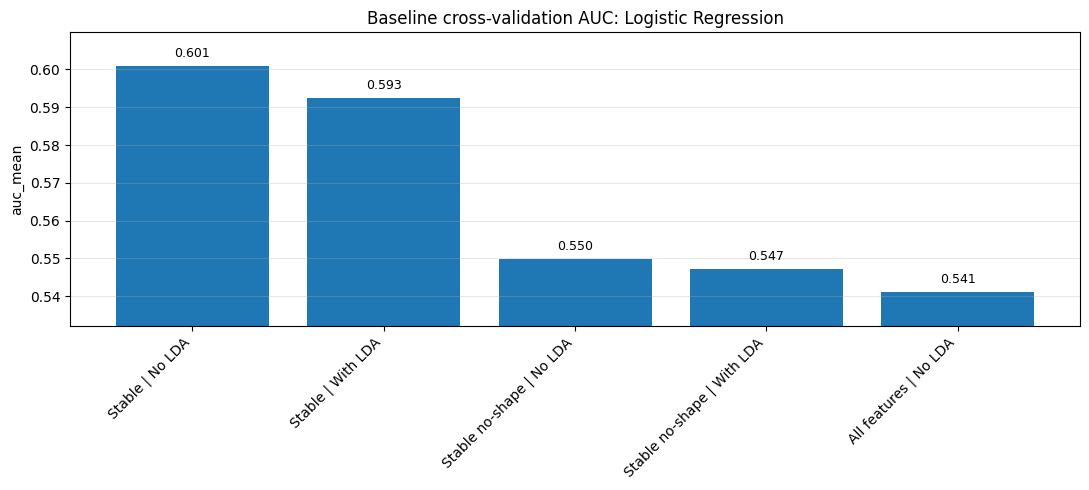

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_Logistic_Regression.png


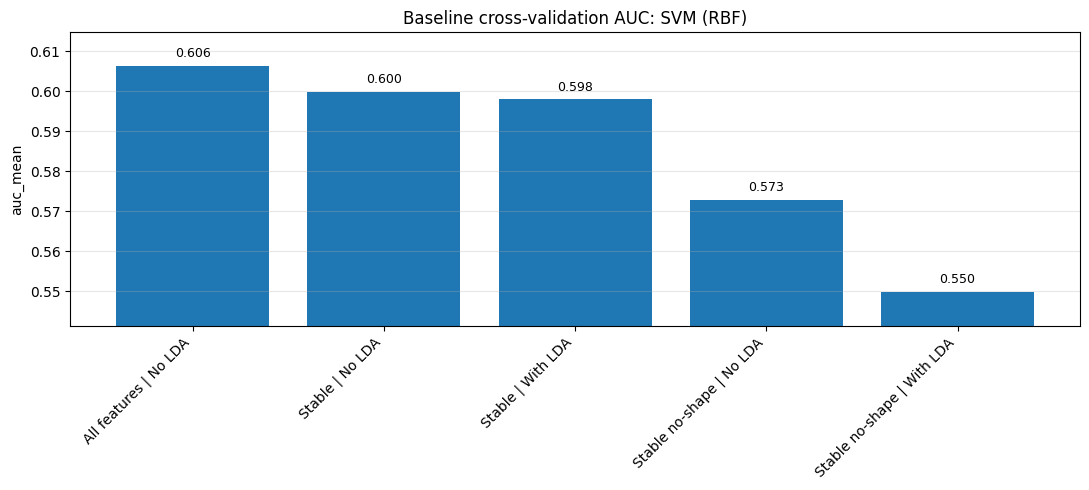

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_SVM_RBF.png


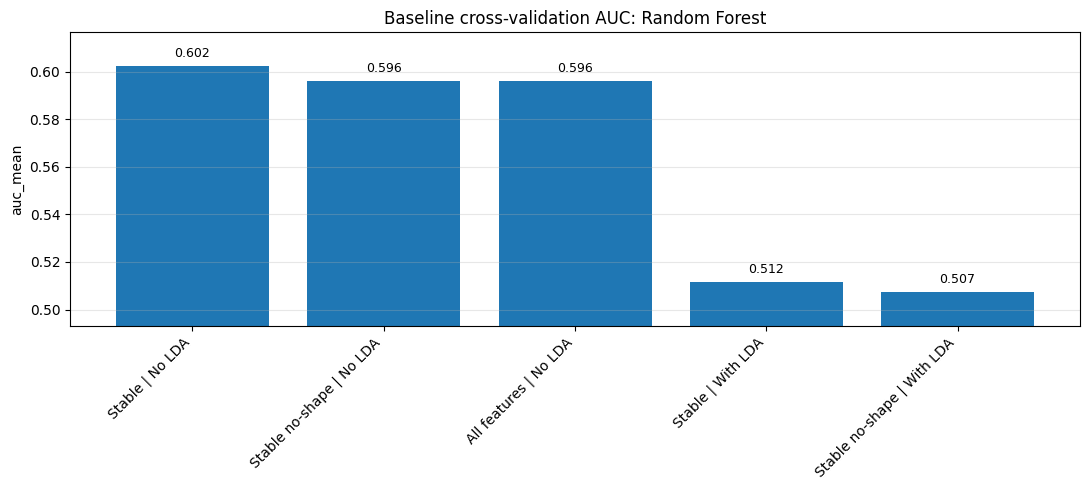

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_Random_Forest.png


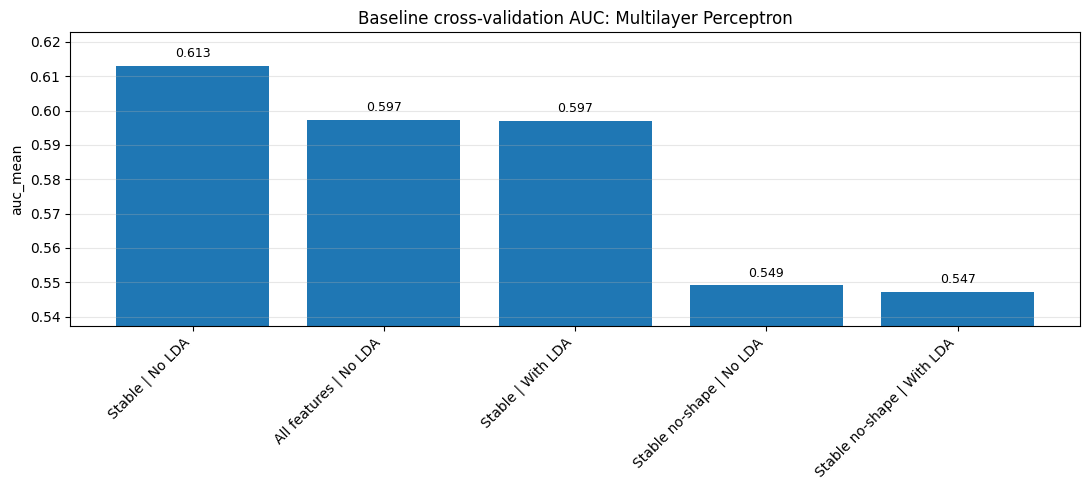

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_Multilayer_Perceptron.png


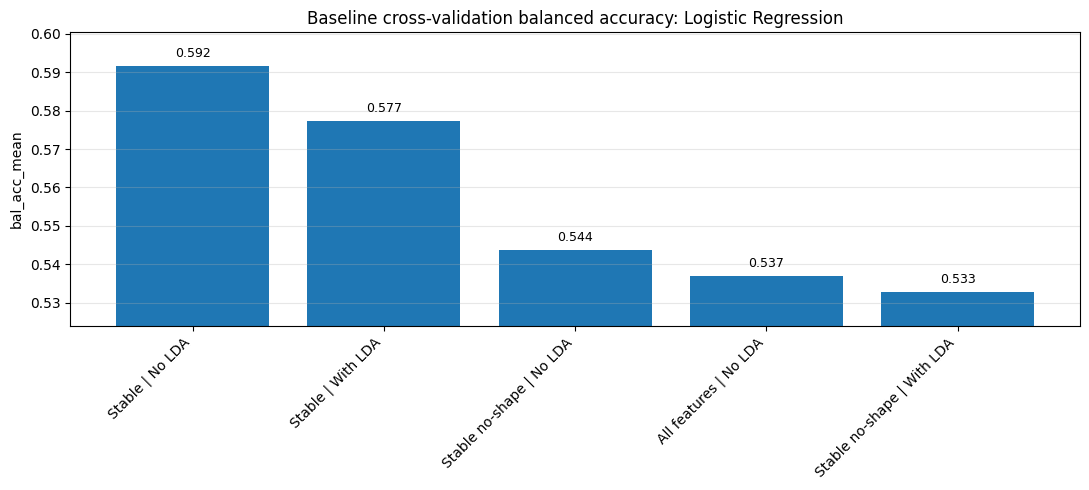

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_Logistic_Regression.png


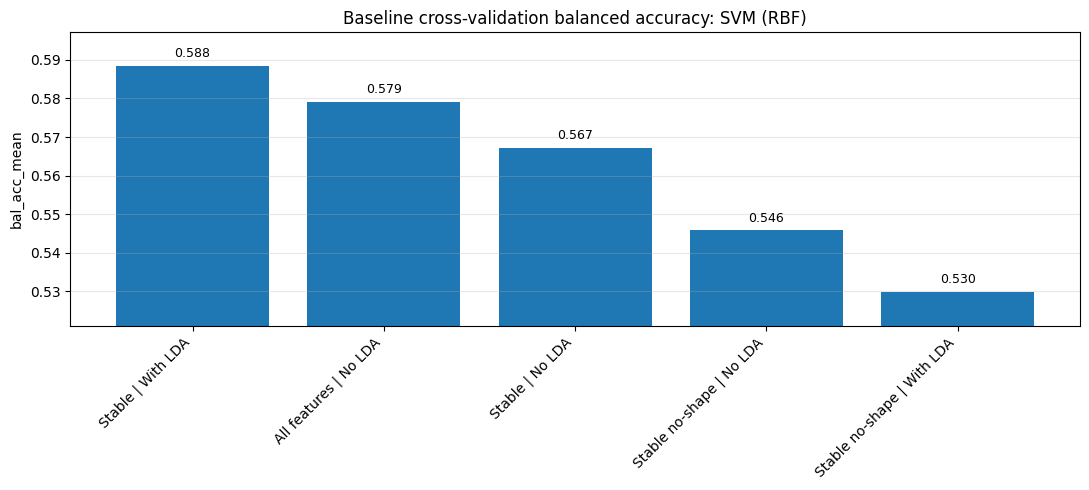

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_SVM_RBF.png


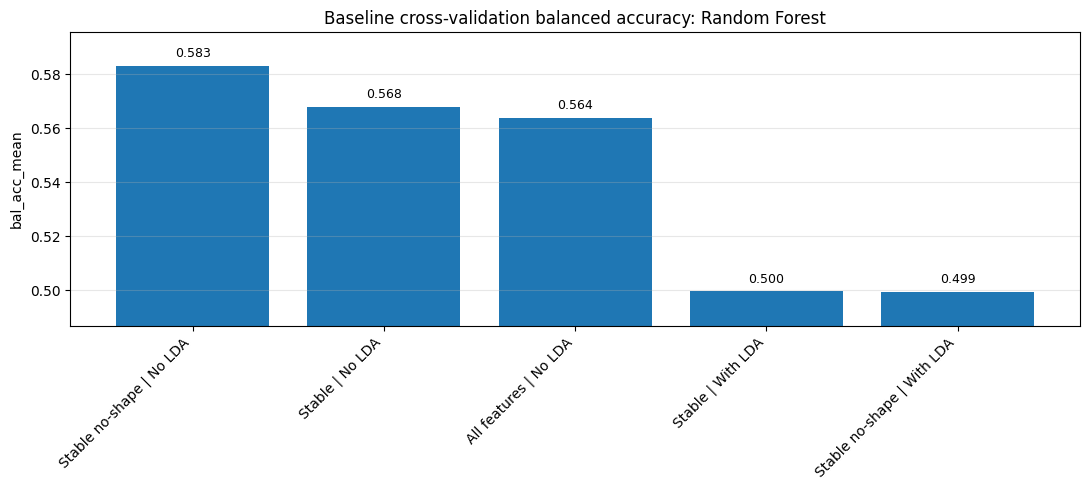

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_Random_Forest.png


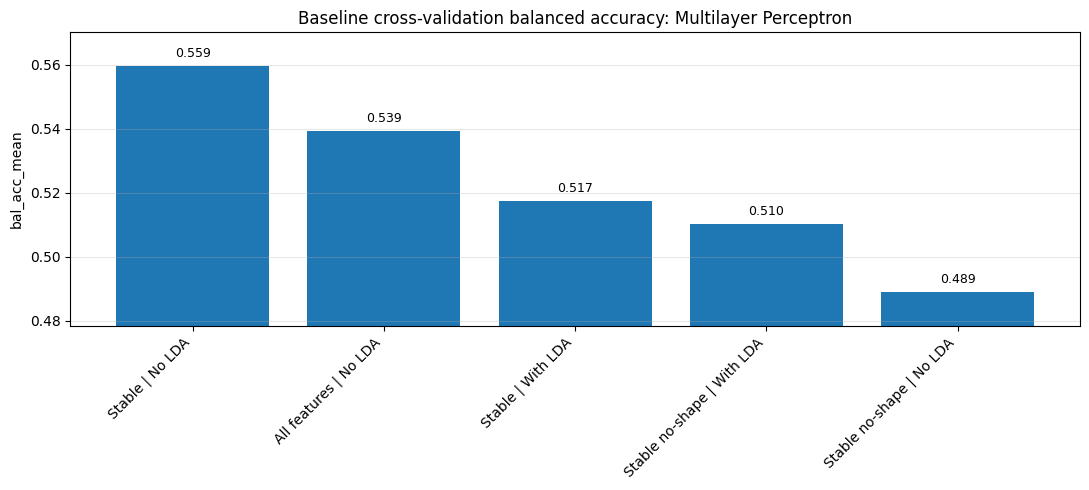

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_Multilayer_Perceptron.png


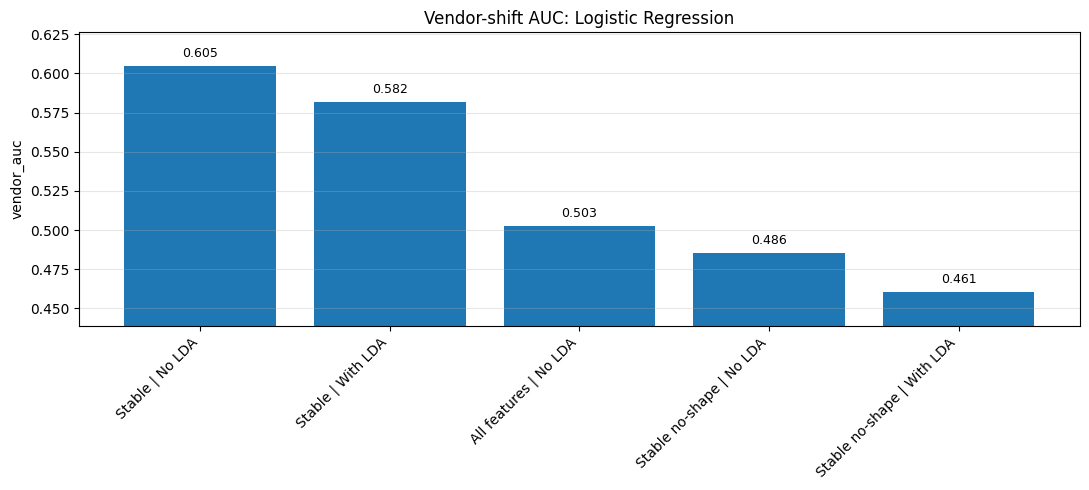

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_Logistic_Regression.png


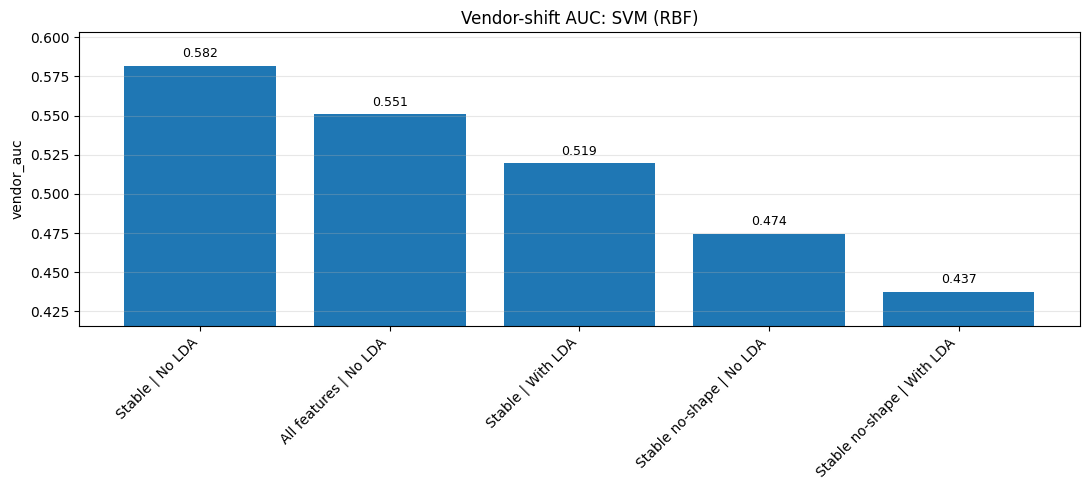

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_SVM_RBF.png


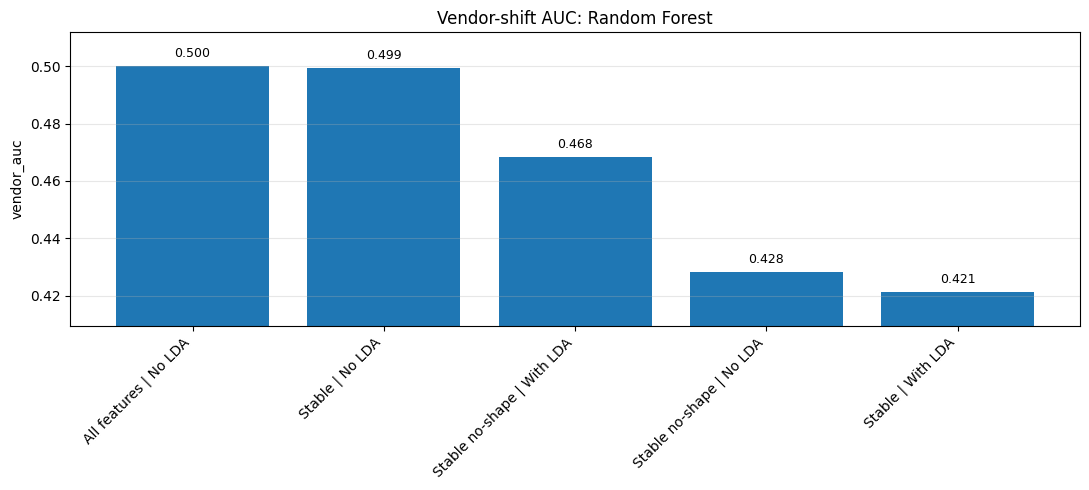

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_Random_Forest.png


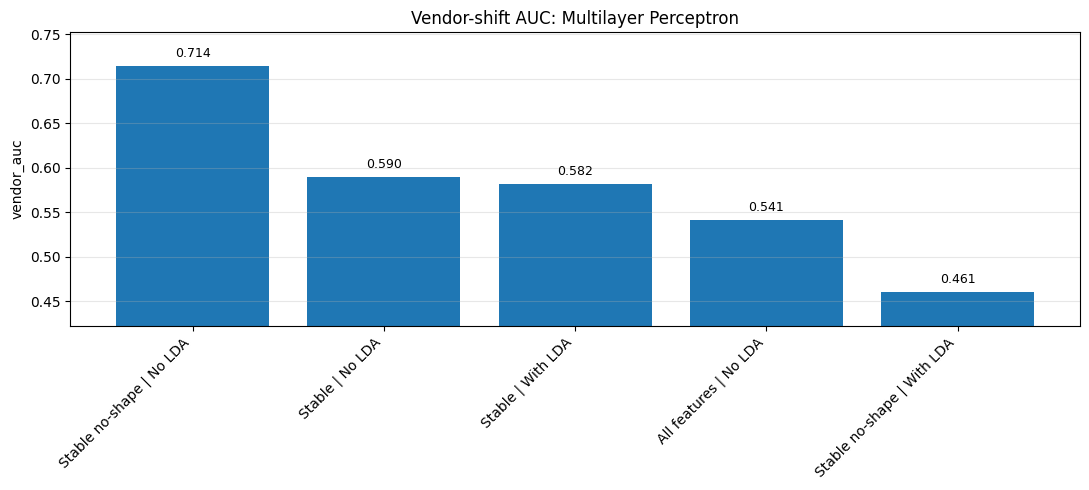

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_Multilayer_Perceptron.png


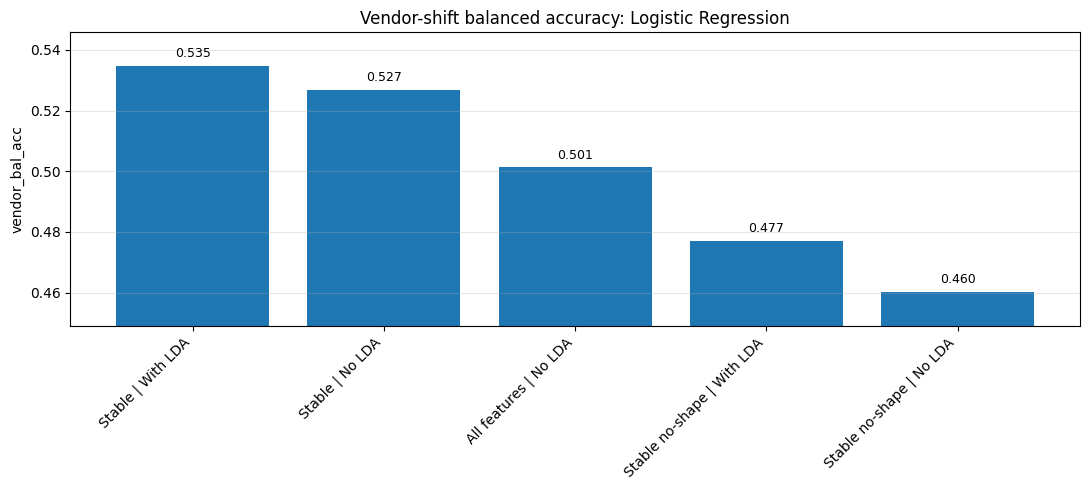

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_Logistic_Regression.png


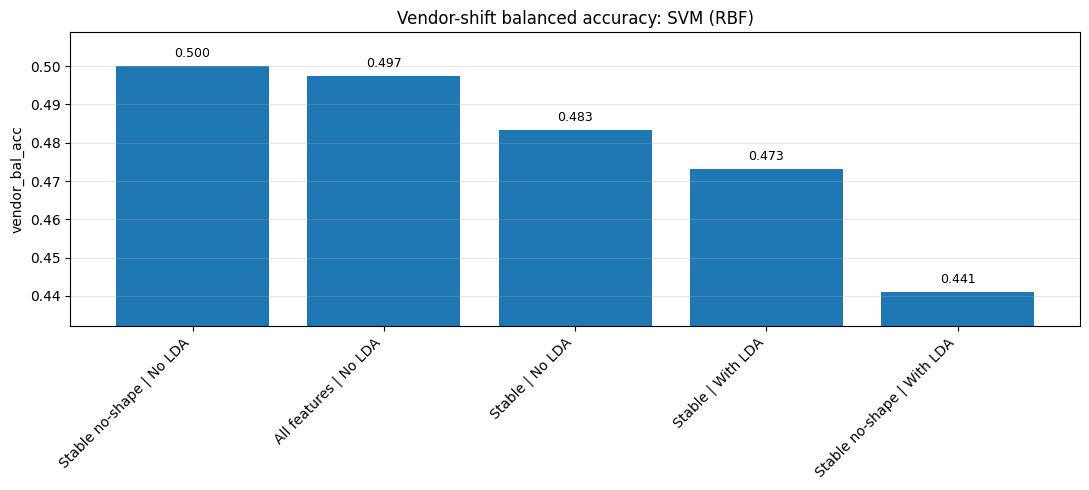

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_SVM_RBF.png


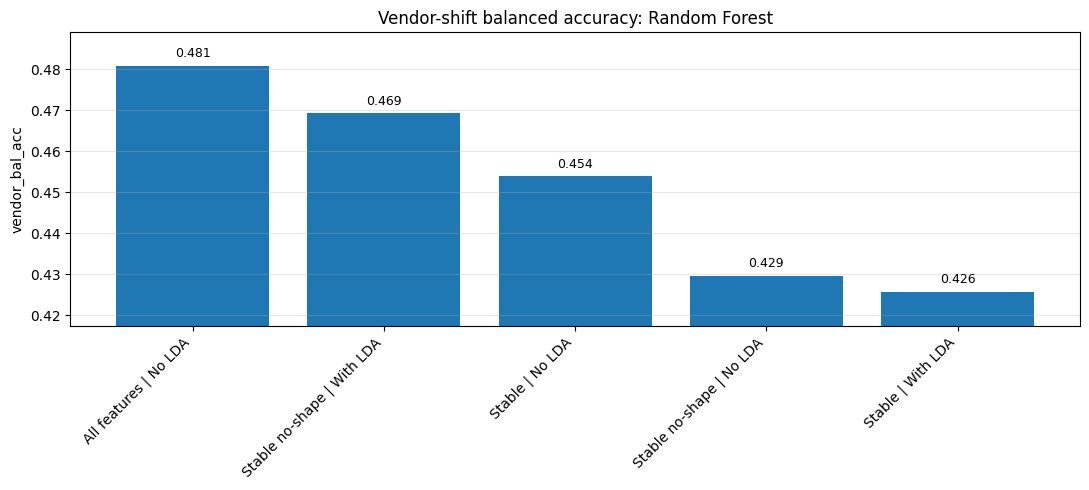

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_Random_Forest.png


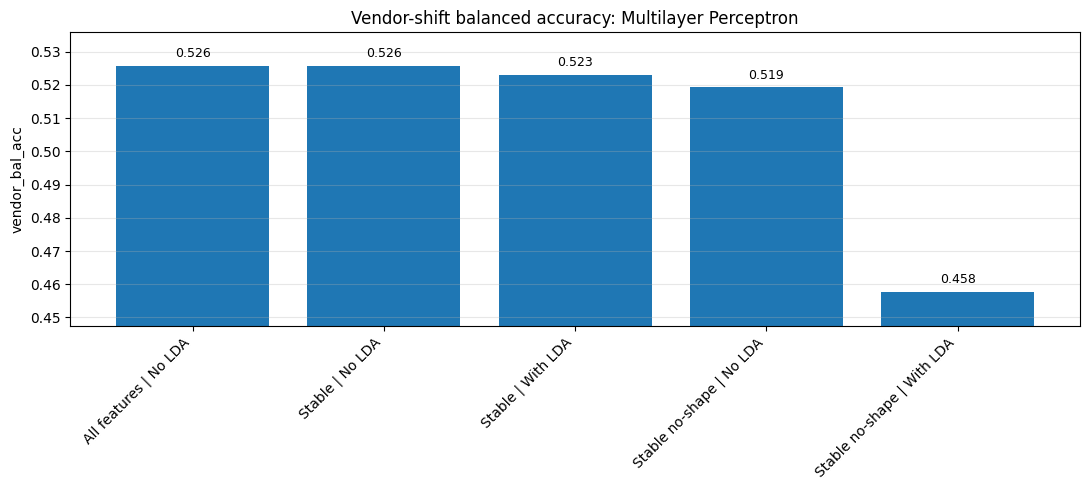

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_Multilayer_Perceptron.png


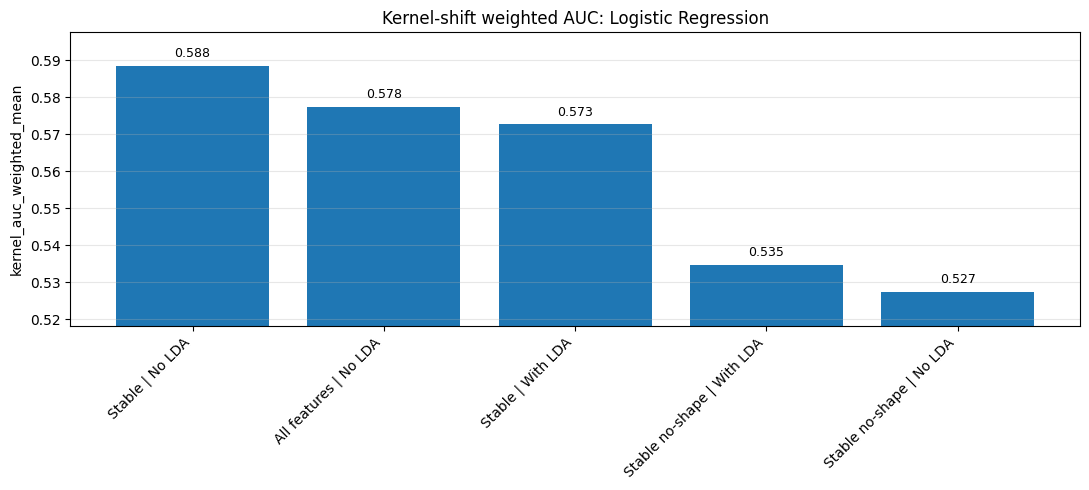

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_Logistic_Regression.png


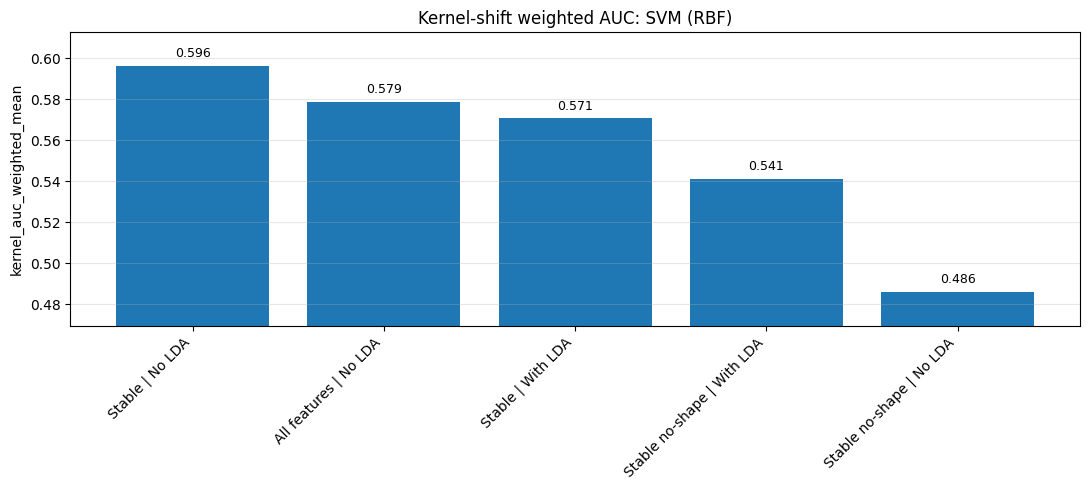

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_SVM_RBF.png


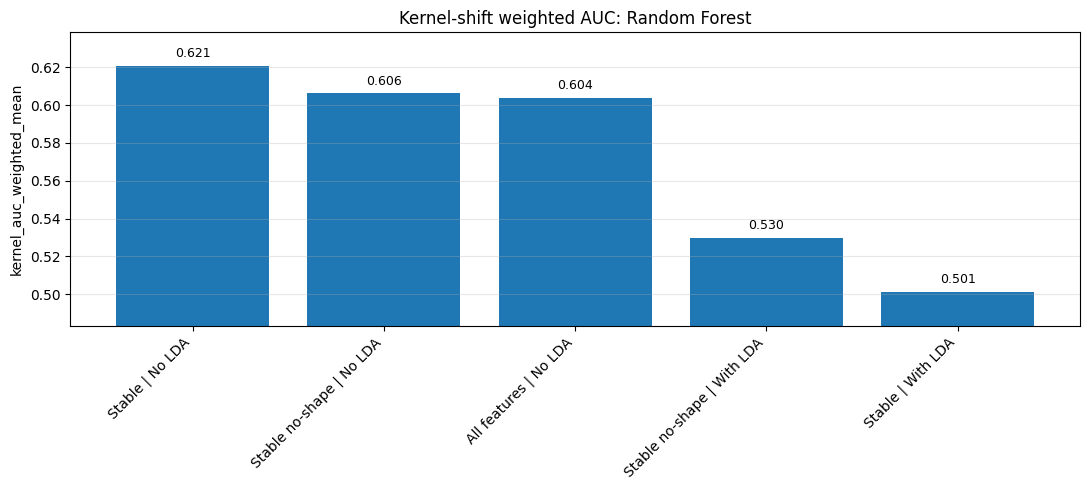

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_Random_Forest.png


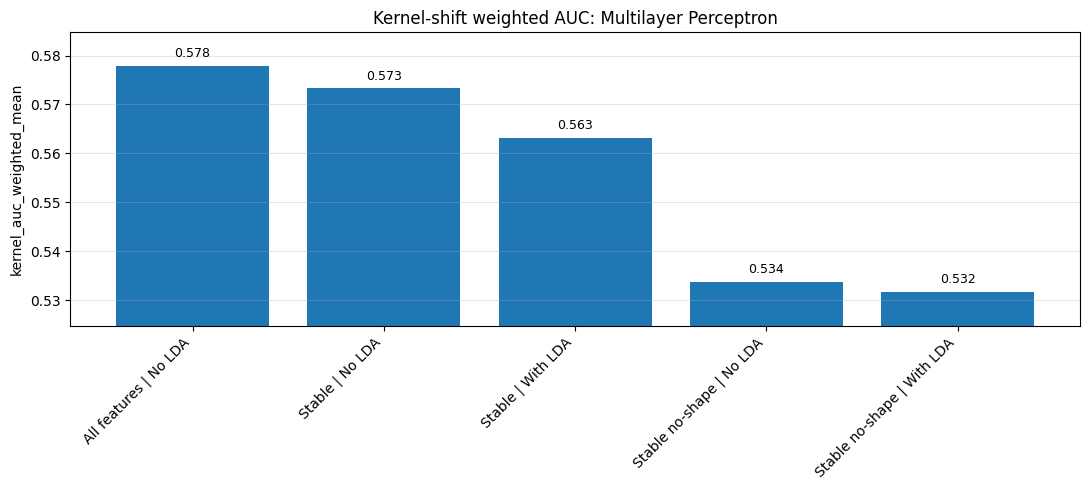

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_Multilayer_Perceptron.png


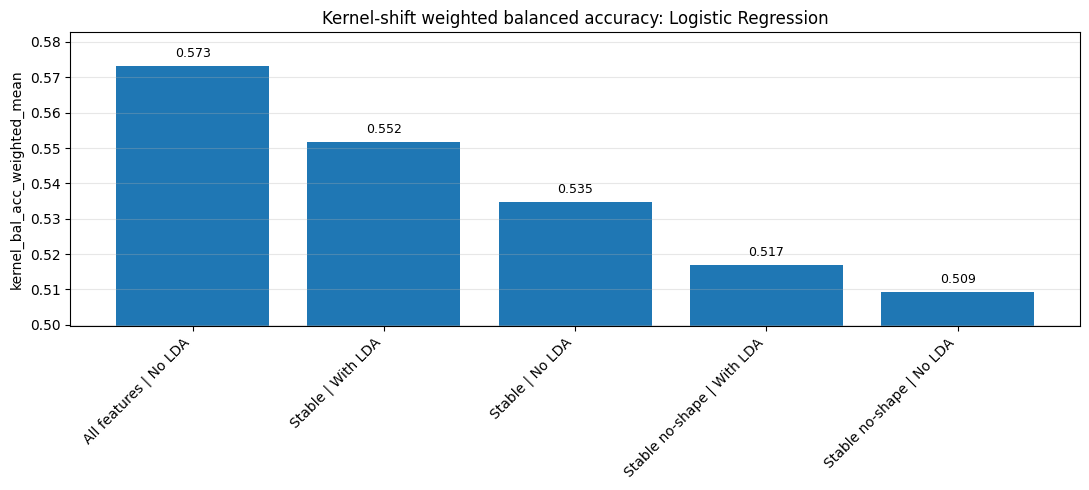

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_Logistic_Regression.png


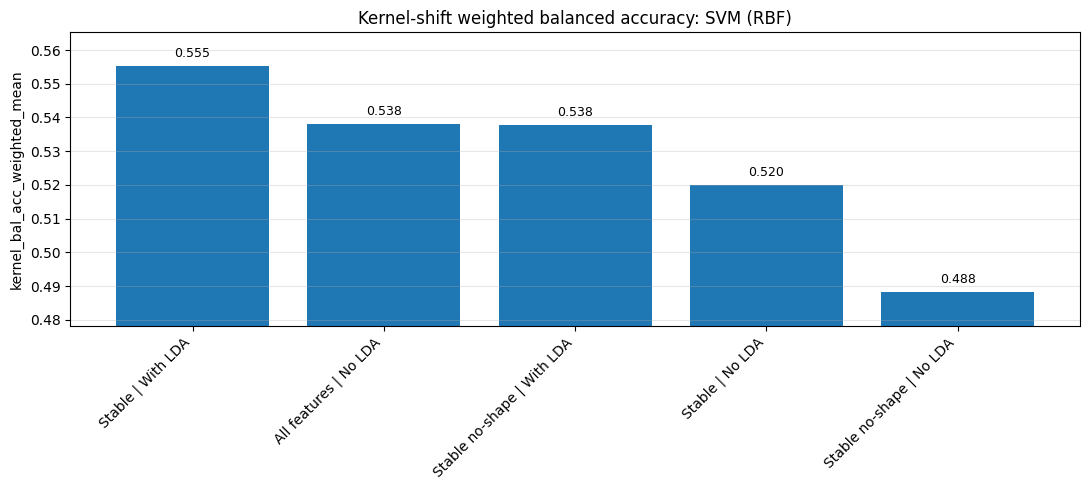

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_SVM_RBF.png


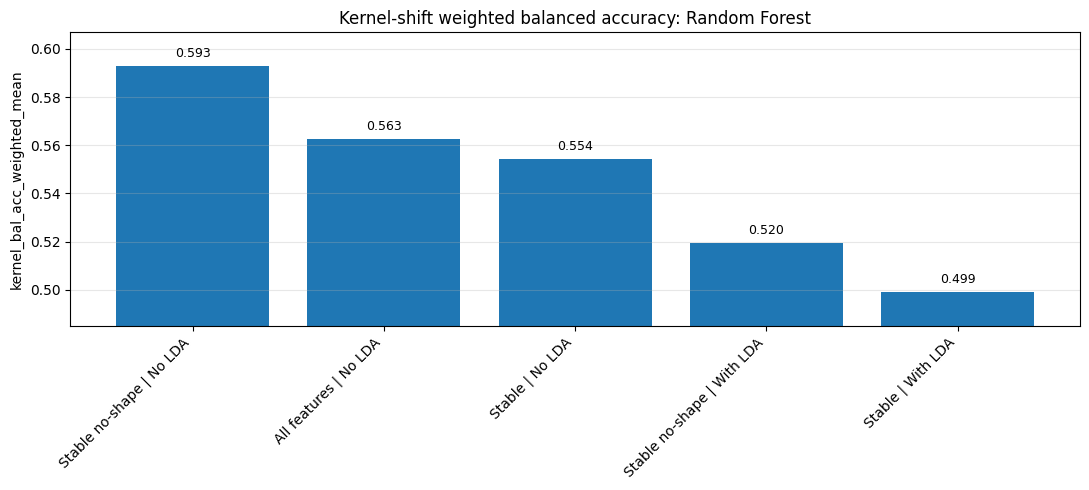

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_Random_Forest.png


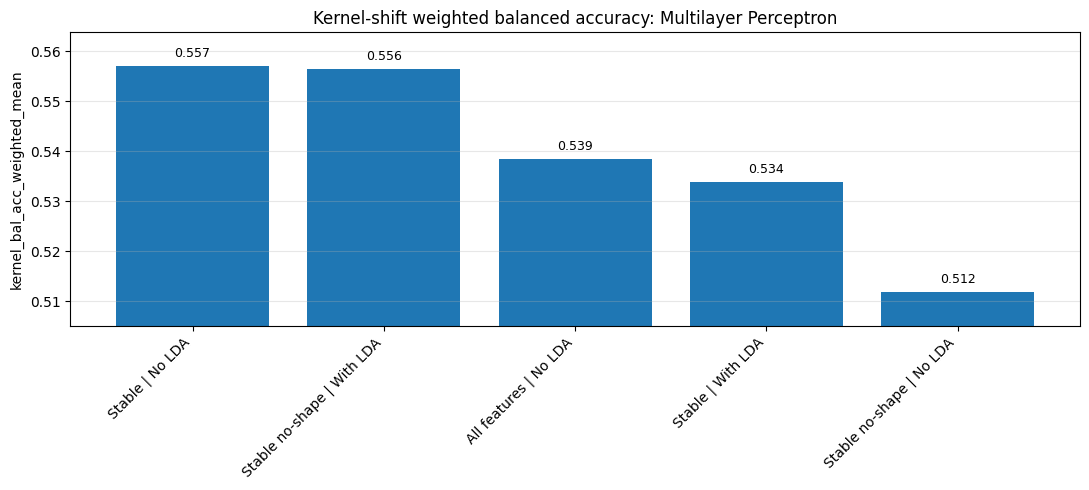

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_Multilayer_Perceptron.png


In [10]:
# ==========================================
# Cell 9: Plot ML results
# ==========================================

def get_zoomed_ylim(values, lower_bound=0.0, upper_bound=1.0, pad_frac=0.15, min_span=0.04):
    """
    Compute a zoomed y-axis range based on the actual values.

    Parameters
    ----------
    values : array-like
        Metric values to plot.
    lower_bound, upper_bound : float
        Hard bounds for the metric range.
    pad_frac : float
        Fraction of the value range used as padding.
    min_span : float
        Minimum y-axis span to avoid over-compression when values are very similar.
    """
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna()

    if vals.empty:
        return lower_bound, upper_bound

    vmin = float(vals.min())
    vmax = float(vals.max())
    span = vmax - vmin

    # If values are extremely close, enforce a minimum visible span
    if span < min_span:
        center = (vmin + vmax) / 2
        y_min = center - min_span / 2
        y_max = center + min_span / 2
    else:
        pad = span * pad_frac
        y_min = vmin - pad
        y_max = vmax + pad

    # Clip to valid metric bounds
    y_min = max(lower_bound, y_min)
    y_max = min(upper_bound, y_max)

    # Safety check in case clipping makes the span too small again
    if (y_max - y_min) < min_span:
        center = (y_min + y_max) / 2
        y_min = max(lower_bound, center - min_span / 2)
        y_max = min(upper_bound, center + min_span / 2)

    return y_min, y_max


def plot_metric_bar(df: pd.DataFrame, metric_col: str, title: str, out_name: str):
    """
    Grouped bar plot by model with zoomed y-axis so differences are easier to see.
    """
    if df.empty or metric_col not in df.columns:
        print(f"Skipping plot {out_name}: missing {metric_col}")
        return

    plot_df = df.copy()
    plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["lda"]

    for model_name in MODEL_KEYS:
        d = plot_df[plot_df["model"].eq(model_name)].copy()

        if d.empty:
            continue

        # Sort bars by metric value for easier visual comparison
        d = d.sort_values(metric_col, ascending=False).reset_index(drop=True)

        y_min, y_max = get_zoomed_ylim(d[metric_col])

        plt.figure(figsize=(11, 5))
        bars = plt.bar(d["label"], d[metric_col])

        plt.xticks(rotation=45, ha="right")
        plt.ylabel(metric_col)
        plt.title(f"{title}: {model_name}")
        plt.ylim(y_min, y_max)
        plt.grid(axis="y", alpha=0.3)

        # Optional: annotate values on top of bars
        value_offset = (y_max - y_min) * 0.02
        for bar, val in zip(bars, d[metric_col]):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val + value_offset,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        out_path = OUT_ML_PLOTS / f"{out_name}_{slug(model_name)}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)


plot_metric_bar(baseline_all, "auc_mean", "Baseline cross-validation AUC", "baseline_auc")
plot_metric_bar(baseline_all, "bal_acc_mean", "Baseline cross-validation balanced accuracy", "baseline_bal_acc")
plot_metric_bar(vendor_all, "vendor_auc", "Vendor-shift AUC", "vendor_auc")
plot_metric_bar(vendor_all, "vendor_bal_acc", "Vendor-shift balanced accuracy", "vendor_bal_acc")
plot_metric_bar(kernel_summary_all, "kernel_auc_weighted_mean", "Kernel-shift weighted AUC", "kernel_auc")
plot_metric_bar(kernel_summary_all, "kernel_bal_acc_weighted_mean", "Kernel-shift weighted balanced accuracy", "kernel_bal_acc")

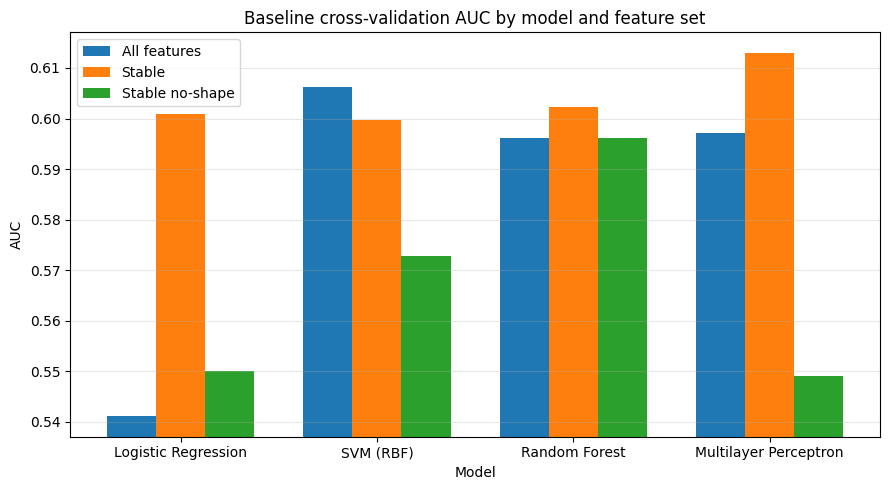

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_No_LDA.png


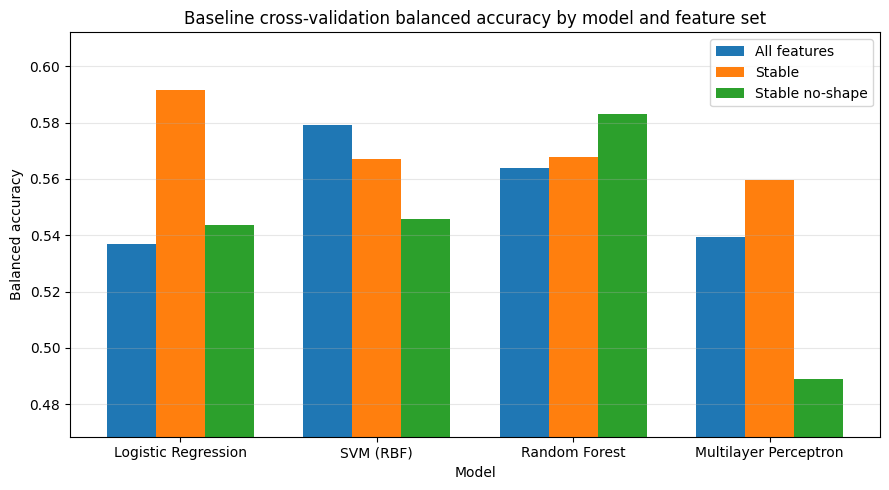

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_No_LDA.png


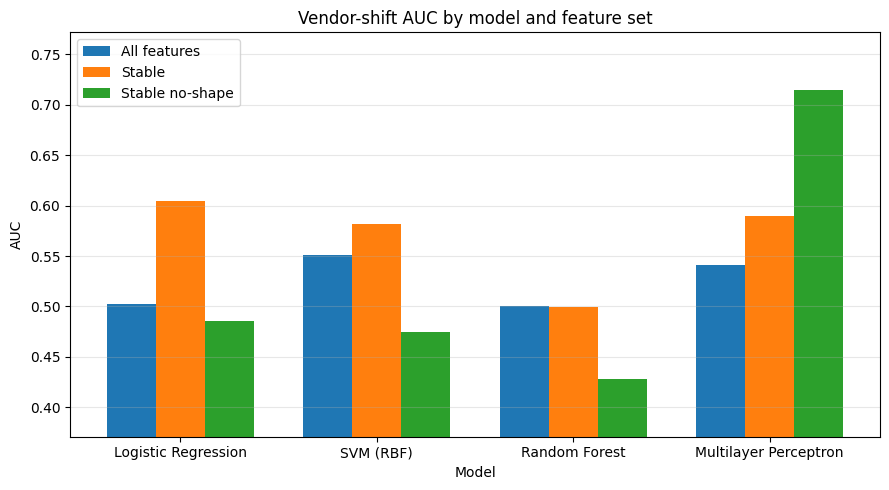

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_No_LDA.png


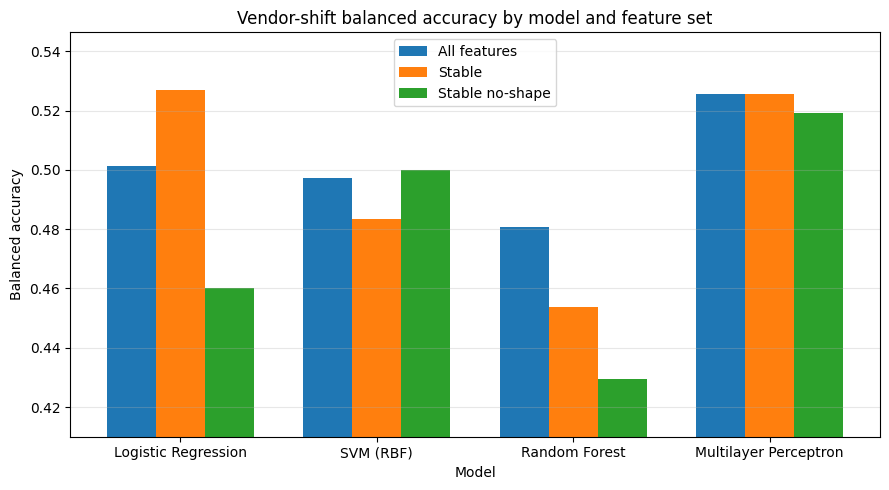

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_No_LDA.png


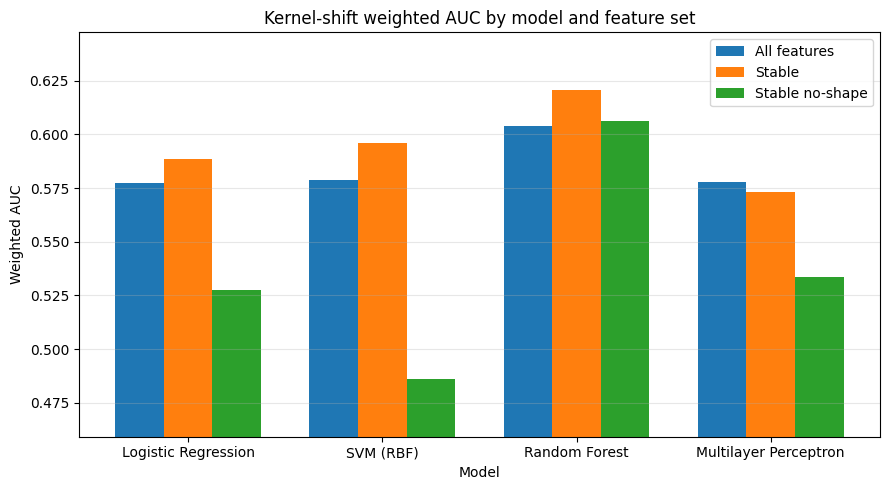

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_No_LDA.png


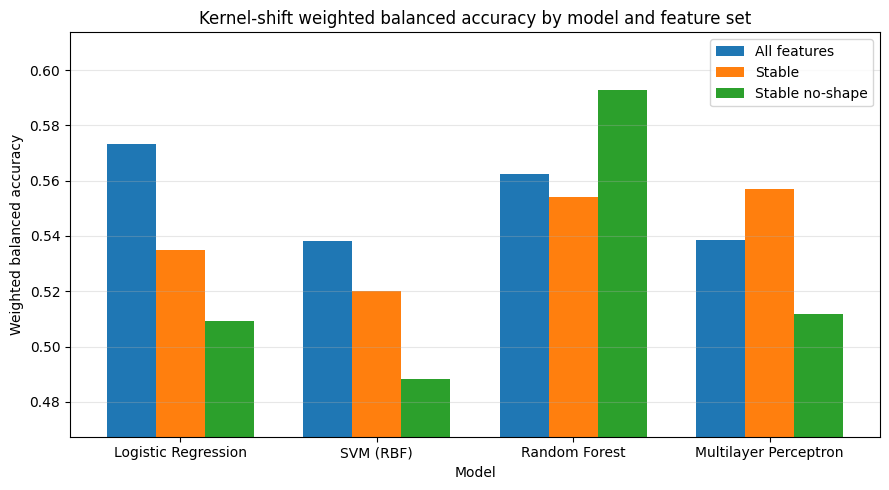

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_No_LDA.png


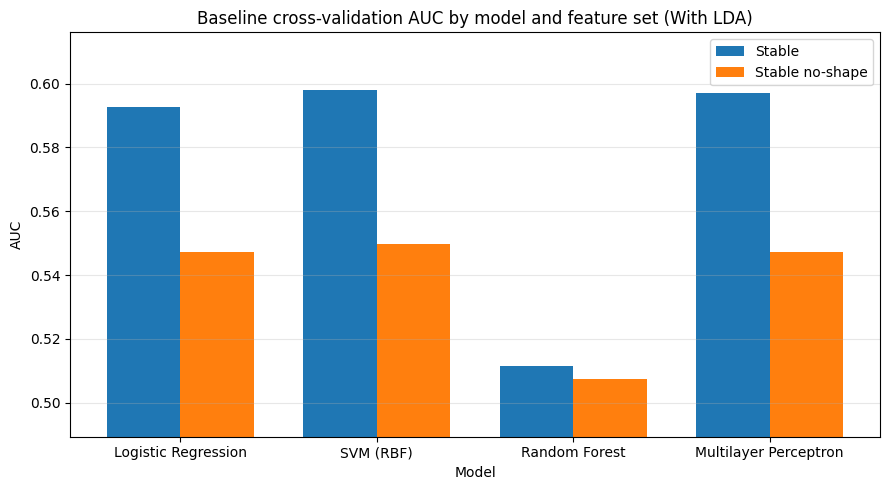

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_auc_With_LDA.png


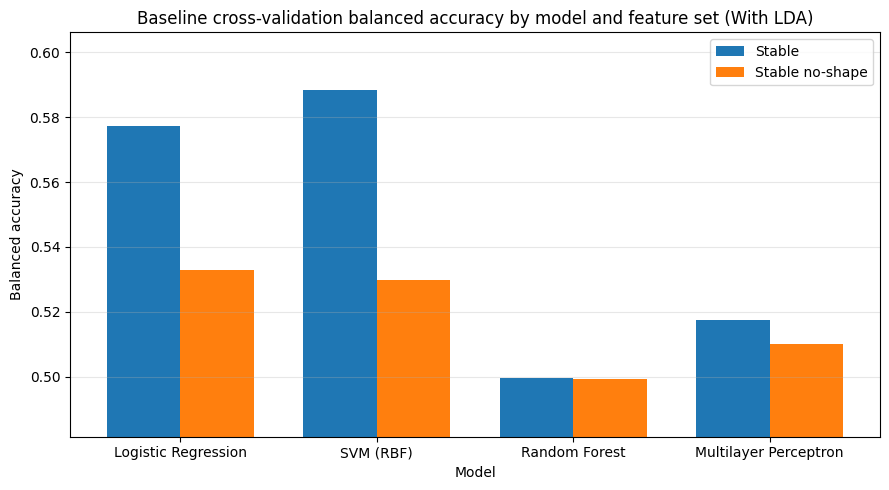

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\baseline_bal_acc_With_LDA.png


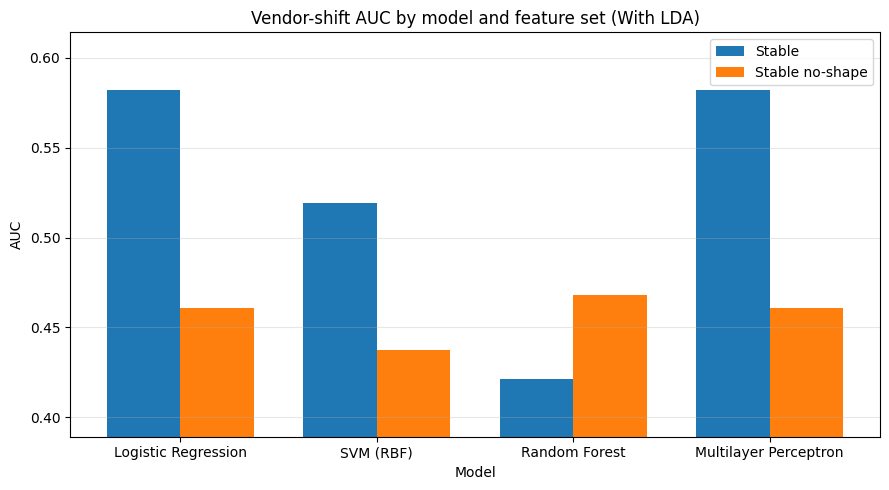

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_auc_With_LDA.png


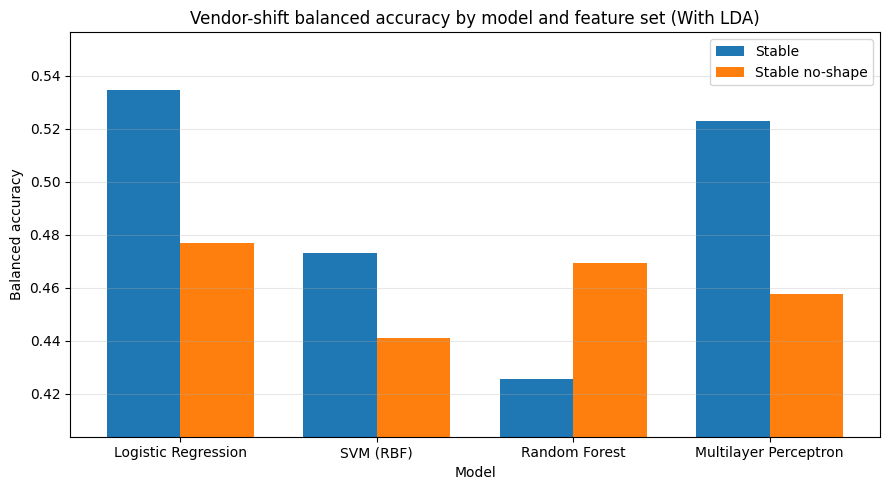

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\vendor_bal_acc_With_LDA.png


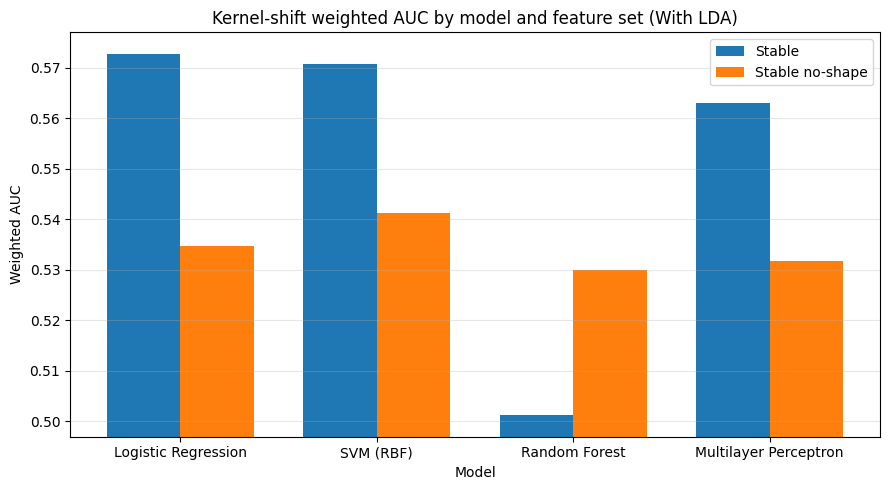

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_auc_With_LDA.png


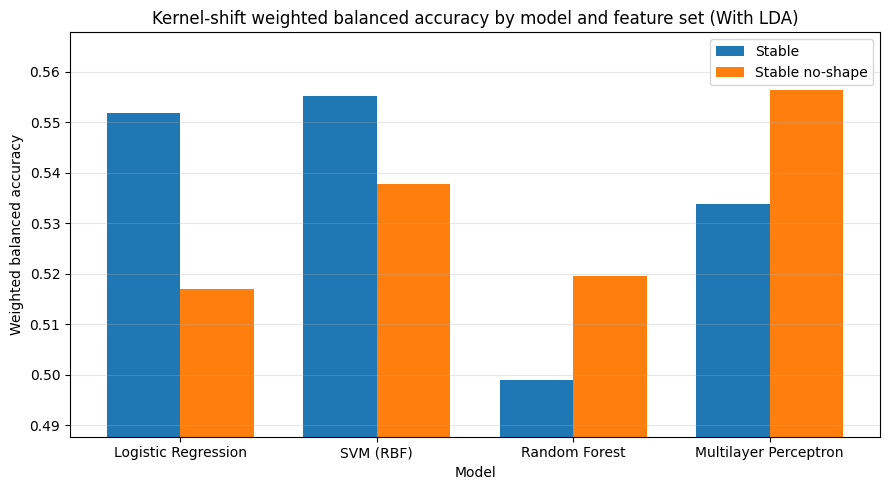

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\kernel_bal_acc_With_LDA.png


In [15]:
# ==========================================
# Cell 9: Plot ML results
# Grouped bar plots by model and feature set
# ==========================================

FEATURE_SET_ORDER = [
    "All features",
    "Stable",
    "Stable no-shape",
]

MODEL_ORDER = list(MODEL_KEYS.keys())


def get_zoomed_ylim(values, lower_bound=0.0, upper_bound=1.0, pad_frac=0.20, min_span=0.08):
    """
    Compute a zoomed y-axis range based on actual metric values.
    This avoids forcing the graph to start at zero.
    """
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna()

    if vals.empty:
        return lower_bound, upper_bound

    vmin = float(vals.min())
    vmax = float(vals.max())
    span = vmax - vmin

    if span < min_span:
        center = (vmin + vmax) / 2
        y_min = center - min_span / 2
        y_max = center + min_span / 2
    else:
        pad = span * pad_frac
        y_min = vmin - pad
        y_max = vmax + pad

    y_min = max(lower_bound, y_min)
    y_max = min(upper_bound, y_max)

    return y_min, y_max


def prettify_metric_name(metric_col: str) -> str:
    """
    Convert metric column names into cleaner axis labels.
    """
    name_map = {
        "auc_mean": "AUC",
        "bal_acc_mean": "Balanced accuracy",
        "vendor_auc": "AUC",
        "vendor_bal_acc": "Balanced accuracy",
        "kernel_auc_weighted_mean": "Weighted AUC",
        "kernel_bal_acc_weighted_mean": "Weighted balanced accuracy",
    }

    return name_map.get(metric_col, metric_col)


def plot_grouped_metric_bar(
    df: pd.DataFrame,
    metric_col: str,
    title: str,
    out_name: str,
    lda_filter: str = "No LDA",
    show_values: bool = False,
):
    """
    Create a grouped bar plot similar to thesis-style ML figures.

    X-axis: model
    Bar groups: feature sets
    Y-axis: selected metric
    """
    if df.empty or metric_col not in df.columns:
        print(f"Skipping plot {out_name}: missing {metric_col}")
        return

    plot_df = df.copy()

    # Use only one LDA condition per plot so the graph stays clean.
    if "lda" in plot_df.columns:
        plot_df = plot_df[plot_df["lda"].eq(lda_filter)].copy()

    if plot_df.empty:
        print(f"Skipping plot {out_name}: no rows for lda={lda_filter}")
        return

    # Keep only expected feature sets and models.
    plot_df = plot_df[
        plot_df["feature_set"].isin(FEATURE_SET_ORDER)
        & plot_df["model"].isin(MODEL_ORDER)
    ].copy()

    if plot_df.empty:
        print(f"Skipping plot {out_name}: no matching feature sets/models")
        return

    # Pivot into model x feature_set format.
    pivot = (
        plot_df
        .pivot_table(
            index="model",
            columns="feature_set",
            values=metric_col,
            aggfunc="mean"
        )
        .reindex(index=MODEL_ORDER, columns=FEATURE_SET_ORDER)
    )

    # Drop feature sets that are entirely missing.
    pivot = pivot.dropna(axis=1, how="all")

    if pivot.empty:
        print(f"Skipping plot {out_name}: empty pivot table")
        return

    values = pivot.values.flatten()
    y_min, y_max = get_zoomed_ylim(values)

    x = np.arange(len(pivot.index))
    n_sets = len(pivot.columns)
    width = 0.75 / n_sets

    plt.figure(figsize=(9, 5))

    for j, feature_set in enumerate(pivot.columns):
        offsets = x - 0.375 + width / 2 + j * width
        bar_values = pivot[feature_set].values

        bars = plt.bar(
            offsets,
            bar_values,
            width,
            label=feature_set
        )

        if show_values:
            value_offset = (y_max - y_min) * 0.015

            for bar, val in zip(bars, bar_values):
                if pd.isna(val):
                    continue

                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + value_offset,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    plt.xticks(x, pivot.index, rotation=0)
    plt.ylabel(prettify_metric_name(metric_col))
    plt.xlabel("Model")

    final_title = title
    if lda_filter != "No LDA":
        final_title = f"{title} ({lda_filter})"

    plt.title(final_title)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    suffix = slug(lda_filter)
    out_path = OUT_ML_PLOTS / f"{out_name}_{suffix}.png"

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# ==========================================
# Main thesis plots: No LDA
# ==========================================

plot_grouped_metric_bar(
    baseline_all,
    "auc_mean",
    "Baseline cross-validation AUC by model and feature set",
    "baseline_auc",
    lda_filter="No LDA"
)

plot_grouped_metric_bar(
    baseline_all,
    "bal_acc_mean",
    "Baseline cross-validation balanced accuracy by model and feature set",
    "baseline_bal_acc",
    lda_filter="No LDA"
)

plot_grouped_metric_bar(
    vendor_all,
    "vendor_auc",
    "Vendor-shift AUC by model and feature set",
    "vendor_auc",
    lda_filter="No LDA"
)

plot_grouped_metric_bar(
    vendor_all,
    "vendor_bal_acc",
    "Vendor-shift balanced accuracy by model and feature set",
    "vendor_bal_acc",
    lda_filter="No LDA"
)

plot_grouped_metric_bar(
    kernel_summary_all,
    "kernel_auc_weighted_mean",
    "Kernel-shift weighted AUC by model and feature set",
    "kernel_auc",
    lda_filter="No LDA"
)

plot_grouped_metric_bar(
    kernel_summary_all,
    "kernel_bal_acc_weighted_mean",
    "Kernel-shift weighted balanced accuracy by model and feature set",
    "kernel_bal_acc",
    lda_filter="No LDA"
)


# ==========================================
# Supplementary plots: With LDA
# ==========================================

plot_grouped_metric_bar(
    baseline_all,
    "auc_mean",
    "Baseline cross-validation AUC by model and feature set",
    "baseline_auc",
    lda_filter="With LDA"
)

plot_grouped_metric_bar(
    baseline_all,
    "bal_acc_mean",
    "Baseline cross-validation balanced accuracy by model and feature set",
    "baseline_bal_acc",
    lda_filter="With LDA"
)

plot_grouped_metric_bar(
    vendor_all,
    "vendor_auc",
    "Vendor-shift AUC by model and feature set",
    "vendor_auc",
    lda_filter="With LDA"
)

plot_grouped_metric_bar(
    vendor_all,
    "vendor_bal_acc",
    "Vendor-shift balanced accuracy by model and feature set",
    "vendor_bal_acc",
    lda_filter="With LDA"
)

plot_grouped_metric_bar(
    kernel_summary_all,
    "kernel_auc_weighted_mean",
    "Kernel-shift weighted AUC by model and feature set",
    "kernel_auc",
    lda_filter="With LDA"
)

plot_grouped_metric_bar(
    kernel_summary_all,
    "kernel_bal_acc_weighted_mean",
    "Kernel-shift weighted balanced accuracy by model and feature set",
    "kernel_bal_acc",
    lda_filter="With LDA"
)

## Cell 10: Optional LDA scores for visualization only

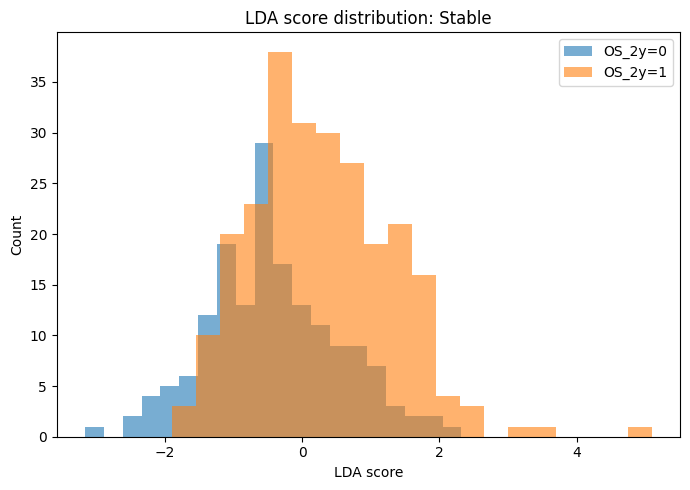

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\06_lda_scores\lda_scores_Stable.csv
Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\lda_scores_Stable.png


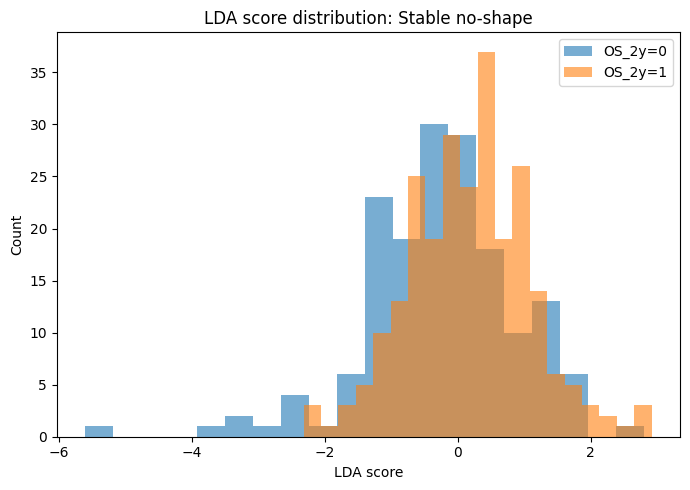

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\06_lda_scores\lda_scores_Stable_no_shape.csv
Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\05_plots\lda_scores_Stable_no_shape.png


In [16]:
# ==========================================
# Cell 10: Export LDA scores for visualization only
# ==========================================

def export_lda_scores_for_feature_set(feature_set_name: str):
    """
    Fits LDA on the full Lung1 cohort only for exploratory visualization.
    This is not used for evaluation.
    """
    if feature_set_name not in X_sets:
        print(f"Feature set not found: {feature_set_name}")
        return

    X = X_sets[feature_set_name]
    if X.shape[1] < 2:
        print(f"Skipping LDA visualization for {feature_set_name}: not enough features.")
        return

    lda_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(n_components=1, solver="svd")),
    ])

    scores = lda_pipe.fit_transform(X, y.values).ravel()

    cols = [ID_COL, LABEL_COL]
    for c in [MANUFACTURER_COL, KERNEL_COL]:
        if c in clinical_df.columns:
            cols.append(c)

    out = clinical_df[cols].copy()
    out["feature_set"] = feature_set_name
    out["lda_score"] = scores

    out_csv = OUT_ML_LDA / f"lda_scores_{slug(feature_set_name)}.csv"
    out.to_csv(out_csv, index=False)

    plt.figure(figsize=(7, 5))
    for cls in sorted(out[LABEL_COL].unique()):
        vals = out.loc[out[LABEL_COL].eq(cls), "lda_score"]
        plt.hist(vals, bins=20, alpha=0.6, label=f"{LABEL_COL}={cls}")
    plt.xlabel("LDA score")
    plt.ylabel("Count")
    plt.title(f"LDA score distribution: {feature_set_name}")
    plt.legend()
    plt.tight_layout()
    out_png = OUT_ML_PLOTS / f"lda_scores_{slug(feature_set_name)}.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_csv)
    print("Saved:", out_png)

for fs in sorted(LDA_ELIGIBLE_FEATURESETS):
    export_lda_scores_for_feature_set(fs)

## Cell 11: Descriptive Logistic Regression coefficients for Stable features

In [13]:
# ==========================================
# Cell 11: Descriptive Logistic Regression coefficients for primary Stable subset
# ==========================================

if "Stable" in X_sets and X_sets["Stable"].shape[1] > 0:
    logreg_model = build_model("logreg", use_lda=False)
    X_stable = X_sets["Stable"]

    logreg_model.fit(X_stable, y.values)

    clf = logreg_model.named_steps["clf"]
    coefs = clf.coef_.ravel()

    coef_table = pd.DataFrame({
        "feature": list(X_stable.columns),
        "coef": coefs,
        "abs_coef": np.abs(coefs),
    }).sort_values("abs_coef", ascending=False)

    out_coef = OUT_ML_COEF / "logreg_stable_coefficients_no_lda.csv"
    coef_table.to_csv(out_coef, index=False)

    display(coef_table.head(25))
    print("Saved coefficients:", out_coef)
else:
    print("Stable feature set not available.")

,feature,coef,abs_coef
2,original_shape_Maximum3DDiameter,0.983696,0.983696
5,original_shape_MinorAxisLength,0.786106,0.786106
6,original_shape_Maximum2DDiameterRow,-0.517614,0.517614
15,original_firstorder_RootMeanSquared,-0.460745,0.460745
16,original_firstorder_10Percentile,-0.458015,0.458015
13,original_gldm_DependenceEntropy,-0.444818,0.444818
25,original_glrlm_RunEntropy,0.388461,0.388461
11,original_shape_Elongation,-0.344595,0.344595
4,original_shape_Maximum2DDiameterColumn,-0.326780,0.326780
9,original_glcm_Idn,-0.264627,0.264627


Saved coefficients: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\07_coefficients\logreg_stable_coefficients_no_lda.csv


## Cell 12: Save ML run manifest

In [14]:
# ==========================================
# Cell 12: Save ML run manifest
# ==========================================

manifest = {
    "project_root": str(PROJECT_ROOT),
    "phantom_stability_csv": str(PHANTOM_STABILITY_CSV),
    "clinical_features_csv": str(CLINICAL_FEATURES_CSV),
    "clinical_qc_csv": str(CLINICAL_QC_CSV),
    "lung1_join_csv": str(LUNG1_JOIN_CSV),
    "label_col": LABEL_COL,
    "manufacturer_col": MANUFACTURER_COL,
    "kernel_col": KERNEL_COL,
    "n_lung1_ml_rows": int(clinical_df.shape[0]),
    "stability_threshold": STABILITY_THRESHOLD,
    "si_threshold_pct": SI_THRESHOLD_PCT,
    "stable_definition": STABLE_DEFINITION,
    "cv_selected_features": int(len(cv_only_df)),
    "stable_features_cv_si_confirmed": int(len(stable_features)),
    "stable_no_shape_features": int(len(stable_noshape_features)),
    "cv_selected_features_failing_si": int(len(cv_features_failing_si)),
    "vendor_train": VENDOR_TRAIN,
    "vendor_test": VENDOR_TEST,
    "kernel_min_cases": KERNEL_MIN_CASES,
    "lda_rule": "LDA is applied only inside sklearn Pipeline for evaluation and only to feature-selected sets.",
    "feature_sets": {name: int(X.shape[1]) for name, X in X_sets.items()},
    "lda_eligible_feature_sets": sorted(LDA_ELIGIBLE_FEATURESETS),
    "models": MODEL_KEYS,
}

manifest_path = OUT_ML_MANIFEST / "run_manifest_ml_lda.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved ML run manifest:", manifest_path)
print("Stable definition:", STABLE_DEFINITION)


Saved ML run manifest: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_ml_lda\08_manifest\run_manifest_ml_lda.json
Stable definition: Stable = overall CV <= 0.1 and overall SI < 20.0%
